# C1 — Hardware-Aware Quantum Embedding-Dimension Selection for NSL-KDD

## Mục tiêu của notebook

Notebook này xác định embedding dimension `n`, đồng thời là số qubit của `ZZFeatureMap`, bằng một quy trình selection nhiều tầng:

1. **Information retention**: candidate phải giữ ít nhất 85% cumulative PCA variance.
2. **Quantum-kernel quality**: trong vùng information-feasible, KTA phải nằm trong 5% so với KTA tốt nhất của chính vùng này.
3. **Hardware-cost proxy**: trong các candidate còn lại, chọn cấu hình có CNOT-weighted hardware-cost proxy thấp nhất.

Finite-shot analysis được thực hiện riêng như một robustness/sanity check cho embedding được chọn và **không tham gia trực tiếp vào selection rule**.

Mục tiêu là xác định một operating point mà:

- không giữ quá ít information;
- không đánh đổi kernel-label alignment để lấy thêm PCA dimensions;
- tránh chi phí two-qubit không cần thiết.

**Câu hỏi trung tâm mà notebook này phải trả lời:**

> Khi tăng số qubit/PCA components, thêm information có thực sự tạo ra quantum-kernel quality tốt hơn không, và liệu additional dimensions có còn chuyển thành quantum-kernel quality tốt hơn ở mức CNOT-weighted hardware-cost proxy hợp lý hay không?

**4 câu hỏi chính trước khi coi C1 là "done":**

1. Khi tăng `n`, information retention thay đổi như thế nào?
2. Khi tăng `n`, quantum-kernel quality thay đổi như thế nào?
3. Khi kết hợp hai constraint trên, vùng embedding khả thi còn những `n` nào?
4. Trong vùng khả thi đó, hardware cost chọn operating point nào?

Finite-shot analysis được báo cáo riêng để kiểm tra độ ổn định của kernel đối với measurement sampling noise, không dùng để quyết định `n`.

**Cấu trúc notebook:**

```
Block A — Existing classical embedding analysis
    1. Configuration
    2. Load K=20 dataset
    3. V(n), DBI(n), 1/DBI(n), Q(n), Fisher (diagnostic)
    4. Trade-off table
    5. Pareto diagnostic
    6. Threshold sensitivity
    7. Weight-sensitivity analysis (supplementary)

Block B — Quantum-kernel geometry
    8. Stratified kernel-evaluation subset (fixed seed, dùng chung cho mọi n)
    9. Ideal quantum Gram matrix theo n: KTA(n), effective rank(n), concentration(n)

Block C — Finite-shot robustness validation
    10. Ideal vs finite-shot quantum Gram matrices
    11. D_noise(n), ΔKTA(n)
    12. Shot-sensitivity at n={4,6,10}

Block D — Hardware-aware embedding selection
    13. Information-feasible set
    14. KTA-feasible set
    15. CNOT-weighted hardware-cost proxy minimization
    16. Freeze n*
```


# Block A — Existing classical embedding analysis

## 1. Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import json
import warnings
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
warnings.filterwarnings('ignore')

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# -- Cau hinh chinh (Block A, giong het baseline) --
DATA_TYPE          = 'NSL-KDD'
ALL_N               = list(range(2, 11))     # toan bo candidate, khong loc truoc
REPS                = 2                      # ZZFeatureMap depth

# Information-retention requirement -- co dinh TU TRUOC, khong chon sau khi nhin ket qua
VARIANCE_THRESHOLD  = 0.85
THRESHOLD_GRID      = [0.80, 0.85, 0.90, 0.95]   # chi de kiem tra robustness cua 85%, KHONG de chon lai T

GRID_RESOLUTION     = 30      # cho weight-sensitivity (supplementary, khong dung de chon n)
ANGLE_MAX           = np.pi   # RY/RX gate rotation range [0, pi]

# -- Cau hinh cho Block B/C/D (hardware-aware selection + finite-shot validation) --
N_KERNEL_SUBSET     = 300     # kich thuoc subset dung de tinh quantum Gram matrix -- CO DINH cho moi n
KERNEL_SEED         = GLOBAL_SEED
KTA_TOLERANCE       = 0.05    # eps: KTA(n) >= (1 - eps) * KTA_max_feasible duoc coi la chap nhan duoc
NOISE_SHOTS         = 1024    # finite-shot simulation cho noisy Gram matrix
NOISE_SEED          = GLOBAL_SEED

# -- Duong dan -- dung output tu selectkbest_nslkdd.ipynb --
LABEL_COLS = ['label', 'label_binary', 'label_multiclass', 'attack_category']
DATA_PATHS = {
    'NSL-KDD'  : '../../data/nslkdd/processed_data/NSL_KDD_Train_Cleaned.csv',
    'UNSW-NB15': '../../data/nslkdd/processed_data/UNSW_NB15_Train_Selected.csv',
}
TEST_PATHS = {
    'NSL-KDD'  : '../../data/nslkdd/processed_data/NSL_KDD_Test_Cleaned.csv',
    'UNSW-NB15': '../../data/nslkdd/processed_data/UNSW_NB15_Test_Selected.csv',
}
FEATURE_SELECTOR_PATHS = {
    'NSL-KDD'  : '../../models/nslkdd/feature_selector_k20.joblib',
    'UNSW-NB15': '../../models/nslkdd/feature_selector_k20.joblib',
}

OUTPUT_DIR = '../../data/nslkdd/processed_data'
MODELS_DIR = '../models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print('Config OK')
print(f'  Dataset               : {DATA_TYPE}')
print(f'  Candidate n range     : {ALL_N}  (danh gia day du, khong loc truoc)')
print(f'  Variance threshold T  : {VARIANCE_THRESHOLD:.0%}  (co dinh TU TRUOC)')
print(f'  Threshold grid check  : {THRESHOLD_GRID}  (chi de test robustness)')
print(f'  ANGLE_MAX             : {ANGLE_MAX:.6f} rad  (= pi, RY gate range)')
print(f'  Kernel subset size    : {N_KERNEL_SUBSET}  (fixed seed={KERNEL_SEED}, dung chung cho moi n)')
print(f'  KTA tolerance eps     : {KTA_TOLERANCE:.0%}')
print(f'  Noise shots           : {NOISE_SHOTS}')


Config OK
  Dataset               : NSL-KDD
  Candidate n range     : [2, 3, 4, 5, 6, 7, 8, 9, 10]  (danh gia day du, khong loc truoc)
  Variance threshold T  : 85%  (co dinh TU TRUOC)
  Threshold grid check  : [0.8, 0.85, 0.9, 0.95]  (chi de test robustness)
  ANGLE_MAX             : 3.141593 rad  (= pi, RY gate range)
  Kernel subset size    : 300  (fixed seed=42, dung chung cho moi n)
  KTA tolerance eps     : 5%
  Noise shots           : 1024


## 2. Tải dữ liệu (K=20, sau SelectKBest)

In [2]:
train_df = pd.read_csv(DATA_PATHS[DATA_TYPE])
test_df  = pd.read_csv(TEST_PATHS[DATA_TYPE])

feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]

# Load selector joblib va transform (KHONG fit lai)
selector     = joblib.load(FEATURE_SELECTOR_PATHS[DATA_TYPE])
X_train_raw  = selector.transform(train_df[feature_cols].to_numpy(dtype=np.float32))
X_test_raw   = selector.transform(test_df[feature_cols].to_numpy(dtype=np.float32))

selected_mask  = selector.get_support()
selected_feats = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]

y_train = train_df['label_binary'].to_numpy(dtype=np.int64)
y_test  = test_df['label_binary'].to_numpy(dtype=np.int64)

y = y_train
X = X_train_raw

print(f'Dataset  : {DATA_TYPE}')
print(f'Train    : {X_train_raw.shape}  ({X_train_raw.shape[1]} features sau SelectKBest, K=20)')
print(f'Test     : {X_test_raw.shape}')
print(f'NaN train: {np.isnan(X_train_raw).sum()} | NaN test: {np.isnan(X_test_raw).sum()}')
unique, counts = np.unique(y_train, return_counts=True)
print('\nPhan bo label_binary (train):')
for u, c in zip(unique, counts):
    print(f'  {u} : {c:,}  ({c/len(y_train):.1%})')


Dataset  : NSL-KDD
Train    : (125973, 20)  (20 features sau SelectKBest, K=20)
Test     : (22544, 20)
NaN train: 0 | NaN test: 0

Phan bo label_binary (train):
  0 : 67,343  (53.5%)
  1 : 58,630  (46.5%)


## 3. Metric functions và đánh giá `n = 2..10`

Ba metric độc lập:

$$V(n) = \sum_{k \le n} \lambda_k / \sum_k \lambda_k \qquad
\widetilde{F}(n) = \frac{1}{\mathrm{DBI}(n)} \qquad
Q(n) = \frac{N_{1q}(n) + 5\,N_{\mathrm{CNOT}}(n)}{Q_{\max}}$$

trong đó mỗi layer có $N_{\mathrm{ZZ}}(n) = r\binom{n}{2}$ cặp ZZ interaction, và mỗi ZZ interaction được decompose thành một chuỗi CNOT–RZ–CNOT, tức là:

$$N_{\mathrm{CNOT}}(n) = 2\,N_{\mathrm{ZZ}}(n) = 2r\binom{n}{2}.$$

Fisher Score `S(n)` cũng được tính nhưng **chỉ để diagnostic**, không nằm trong bất kỳ rule chọn
`n` nào ở Block A. Toàn bộ `ALL_N = 2..10` được đánh giá, không lọc trước.

In [3]:
def calculate_fisher_score(X_pca, y):
    """Fisher Score tung PC -- DIAGNOSTIC ONLY, khong dung de chon n."""
    labels = np.unique(y)
    if len(labels) < 2:
        raise ValueError(f'Can it nhat 2 lop, nhan {len(labels)}.')
    mu_all = np.mean(X_pca, axis=0)
    S_B = np.zeros(X_pca.shape[1])
    S_W = np.zeros(X_pca.shape[1])
    for lbl in labels:
        Xk = X_pca[y == lbl]
        nk = len(Xk)
        mu_k = np.mean(Xk, axis=0)
        S_B += nk * (mu_k - mu_all) ** 2
        S_W += nk * np.var(Xk, axis=0)
    scores = S_B / (S_W + 1e-8)
    return scores, float(np.mean(scores))


def n_zz_pairs(n, reps=REPS):
    """
    N_ZZ(n) = r * C(n, 2) -- number of pairwise ZZ interactions ("ZZ interaction
    pairs / layer") produced by a full-entanglement ZZFeatureMap with `reps` layers.
    """
    return (n * (n - 1) // 2) * reps


def n_cnot_gates(n, reps=REPS):
    """
    N_CNOT(n) = 2 * N_ZZ(n).

    Each pairwise ZZ interaction is decomposed into a CNOT-RZ-CNOT sequence,
    resulting in two physical CNOT gates per ZZ interaction.
    """
    return 2 * n_zz_pairs(n, reps)


def quantum_hardware_cost(n, reps=REPS, normalize_max=10):
    """
    Q(n) = [N_1q(n) + 5 * N_CNOT(n)] / Q_max   -- CNOT-weighted hardware cost.

    Each pairwise ZZ interaction is decomposed into a CNOT-RZ-CNOT sequence,
    resulting in two CNOT gates per interaction:
        N_ZZ(n)   = r * C(n, 2)     -- ZZ interaction pairs / layer
        N_CNOT(n) = 2 * N_ZZ(n)     -- actual two-qubit CNOT gate count
      - 1-qubit gates : N_1q(n) = n * reps      [O(n)]
      - CNOT gates    : N_CNOT(n)               [O(n^2)] -- penalty x5 (2Q error rate >> 1Q)
    """
    n1q  = n * reps
    ncx  = n_cnot_gates(n, reps)
    raw  = n1q + 5 * ncx

    n1q_max = normalize_max * reps
    ncx_max = n_cnot_gates(normalize_max, reps)
    raw_max = n1q_max + 5 * ncx_max
    return raw / raw_max


def simplex_grid(resolution):
    """Sinh cac diem (a, b, g) deu tren simplex a+b+g=1."""
    points = []
    for i in range(resolution + 1):
        for j in range(resolution + 1 - i):
            k = resolution - i - j
            points.append((i / resolution, j / resolution, k / resolution))
    return np.array(points)


results_all = []
print(f'{"n":>4} | {"V(n)":>8} | {"DBI":>8} | {"1/DBI":>8} | {"Fisher":>8} | {"Q(n)":>8}')
print('-' * 62)

for n in ALL_N:
    pca_tmp  = PCA(n_components=n, random_state=GLOBAL_SEED)
    X_pca    = pca_tmp.fit_transform(X)   # fit tren train ONLY -- zero leakage
    V_n      = float(np.sum(pca_tmp.explained_variance_ratio_))

    per_pc_scores, S_n = calculate_fisher_score(X_pca, y)   # diagnostic
    dbi   = davies_bouldin_score(X_pca, y)
    Fe_n  = 1.0 / dbi
    Q_n   = quantum_hardware_cost(n)
    N_zz_n   = n_zz_pairs(n)
    N_cnot_n = n_cnot_gates(n)

    # Scaler fit tren FULL TRAIN (khong fit lai tren kernel subset o Block B --
    # sua loi scaler-leakage: xem review section 1).
    scaler_tmp   = MinMaxScaler(feature_range=(0.0, ANGLE_MAX))
    X_angles_tmp = scaler_tmp.fit_transform(X_pca)

    results_all.append({
        'n'            : n,
        'V_n'          : V_n,
        'DBI'          : dbi,
        'Fe_n'         : Fe_n,
        'S_n'          : S_n,
        'per_pc_scores': per_pc_scores,
        'Q_n'          : Q_n,
        'N_zz'         : N_zz_n,
        'N_cnot'       : N_cnot_n,
        'X_pca'        : X_pca,
        'pca_obj'      : pca_tmp,
        'scaler_obj'   : scaler_tmp,
    })
    print(f'{n:>4} | {V_n:>8.4f} | {dbi:>8.4f} | {Fe_n:>8.4f} | {S_n:>8.4f} | {Q_n:>8.4f}')


   n |     V(n) |      DBI |    1/DBI |   Fisher |     Q(n)
--------------------------------------------------------------
   2 |   0.7418 |   0.8746 |   1.1434 |   0.9413 |   0.0261
   3 |   0.8210 |   1.0179 |   0.9824 |   0.6275 |   0.0717
   4 |   0.8662 |   1.0846 |   0.9220 |   0.4711 |   0.1391
   5 |   0.9040 |   1.1311 |   0.8841 |   0.3777 |   0.2283
   6 |   0.9391 |   1.1718 |   0.8534 |   0.3154 |   0.3391
   7 |   0.9524 |   1.1850 |   0.8439 |   0.2717 |   0.4717
   8 |   0.9643 |   1.1985 |   0.8344 |   0.2399 |   0.6261
   9 |   0.9729 |   1.2065 |   0.8288 |   0.2144 |   0.8022
  10 |   0.9810 |   1.2140 |   0.8237 |   0.1957 |   1.0000


## 4. Bảng trade-off đầy đủ (Table C1)

|   n | V(n) | 1/DBI | Fisher (diag.) | ZZ interaction pairs/layer | CNOTs/layer | Q(n) |
|----:|-----:|------:|----------------:|----------------------------:|------------:|-----:|

`V(n)` tăng đơn điệu theo `n`, `1/DBI(n)` giảm đơn điệu theo `n`, `Q(n)` tăng đơn điệu theo `n`.
Đây là một trade-off rõ ràng, đọc trực tiếp từ số liệu — không cần gộp thành một điểm số duy nhất.

In [4]:
df_table = pd.DataFrame([{
    'n'                       : r['n'],
    'V(n)'                    : r['V_n'],
    'DBI'                     : r['DBI'],
    '1/DBI = Fe(n)'           : r['Fe_n'],
    'Fisher (diag.)'          : r['S_n'],
    'ZZ interaction pairs/layer': r['N_zz'],
    'CNOTs/layer'             : r['N_cnot'],
    'Q(n)'                    : r['Q_n'],
} for r in results_all])

display(df_table.style.format({
    'V(n)'          : '{:.4f}',
    'DBI'           : '{:.4f}',
    '1/DBI = Fe(n)' : '{:.4f}',
    'Fisher (diag.)': '{:.4f}',
    'Q(n)'          : '{:.4f}',
}))


,n,V(n),DBI,1/DBI = Fe(n),Fisher (diag.),ZZ interaction pairs/layer,CNOTs/layer,Q(n)
0,2,0.7418,0.8746,1.1434,0.9413,2,4,0.0261
1,3,0.8210,1.0179,0.9824,0.6275,6,12,0.0717
2,4,0.8662,1.0846,0.9220,0.4711,12,24,0.1391
3,5,0.9040,1.1311,0.8841,0.3777,20,40,0.2283
4,6,0.9391,1.1718,0.8534,0.3154,30,60,0.3391
5,7,0.9524,1.1850,0.8439,0.2717,42,84,0.4717
6,8,0.9643,1.1985,0.8344,0.2399,56,112,0.6261
7,9,0.9729,1.2065,0.8288,0.2144,72,144,0.8022
8,10,0.9810,1.2140,0.8237,0.1957,90,180,1.0000


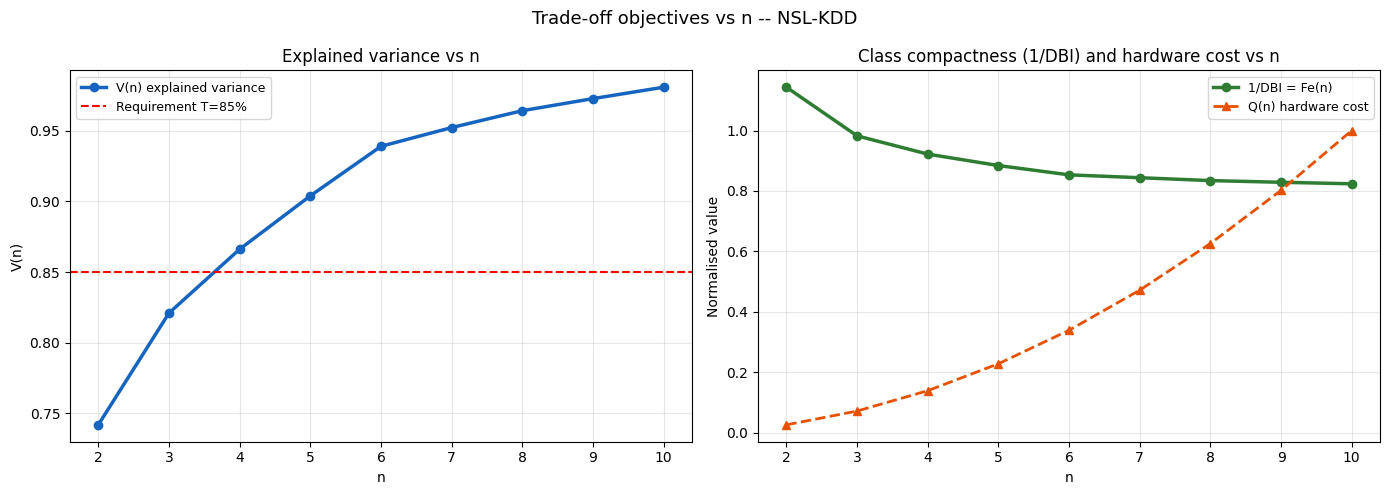

V(n) tang, 1/DBI(n) giam, Q(n) tang -- day la trade-off information vs. separability vs. hardware.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Trade-off objectives vs n -- {DATA_TYPE}', fontsize=13)

n_vals = [r['n'] for r in results_all]
v_vals = [r['V_n'] for r in results_all]
fe_vals = [r['Fe_n'] for r in results_all]
q_vals = [r['Q_n'] for r in results_all]

ax = axes[0]
ax.plot(n_vals, v_vals, 'o-', color='#1565C0', linewidth=2.5, label='V(n) explained variance')
ax.axhline(VARIANCE_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Requirement T={VARIANCE_THRESHOLD:.0%}')
ax.set_xlabel('n'); ax.set_ylabel('V(n)')
ax.set_title('Explained variance vs n')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(n_vals, fe_vals, 'o-', color='#2E7D32', linewidth=2.5, label='1/DBI = Fe(n)')
ax2.plot(n_vals, q_vals, '^--', color='#E65100', linewidth=2, label='Q(n) hardware cost')
ax2.set_xlabel('n'); ax2.set_ylabel('Normalised value')
ax2.set_title('Class compactness (1/DBI) and hardware cost vs n')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/c1_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print('V(n) tang, 1/DBI(n) giam, Q(n) tang -- day la trade-off information vs. separability vs. hardware.')


## 5. Pareto trade-off diagnostic (không dùng để chọn `n`)

Mục tiêu của bước này chỉ là **mô tả** cấu trúc trade-off — không phải để chọn `n`. Kiểm tra
tường minh: Pareto frontier có loại được candidate nào trên bộ 3 mục tiêu `(V(n), Fe(n), −Q(n))`
hay không?

In [6]:
def compute_pareto_frontier(candidates):
    pareto = []
    for i, ri in enumerate(candidates):
        dominated = False
        for j, rj in enumerate(candidates):
            if i == j:
                continue
            geq    = (rj['V_n'] >= ri['V_n'] and rj['Fe_n'] >= ri['Fe_n'] and rj['Q_n'] <= ri['Q_n'])
            strict = (rj['V_n'] > ri['V_n'] or rj['Fe_n'] > ri['Fe_n'] or rj['Q_n'] < ri['Q_n'])
            if geq and strict:
                dominated = True; break
        if not dominated:
            pareto.append(ri)
    return pareto


pareto_points = compute_pareto_frontier(results_all)
pareto_n      = sorted(r['n'] for r in pareto_points)
dominated_n   = sorted(set(ALL_N) - set(pareto_n))

print(f'Pareto-optimal set (over ALL_N={ALL_N}): n in {pareto_n}')
print(f'Dominated: n in {dominated_n if dominated_n else "KHONG CO"}')
print()
if not dominated_n:
    print('>>> Tat ca candidate deu Pareto-optimal -- day la mot trade-off "clean":')
    print('    khong co n nao vua kem hon ve variance, vua kem hon ve compactness, vua dat hon.')
    print('>>> Pareto analysis o day CHI la diagnostic, KHONG duoc dung de chon n (rule chinh o Block D).')
else:
    print(f'>>> Pareto loai duoc {len(dominated_n)} candidate(s): {dominated_n} -- van chi la diagnostic o day.')


Pareto-optimal set (over ALL_N=[2, 3, 4, 5, 6, 7, 8, 9, 10]): n in [2, 3, 4, 5, 6, 7, 8, 9, 10]
Dominated: n in KHONG CO

>>> Tat ca candidate deu Pareto-optimal -- day la mot trade-off "clean":
    khong co n nao vua kem hon ve variance, vua kem hon ve compactness, vua dat hon.
>>> Pareto analysis o day CHI la diagnostic, KHONG duoc dung de chon n (rule chinh o Block D).


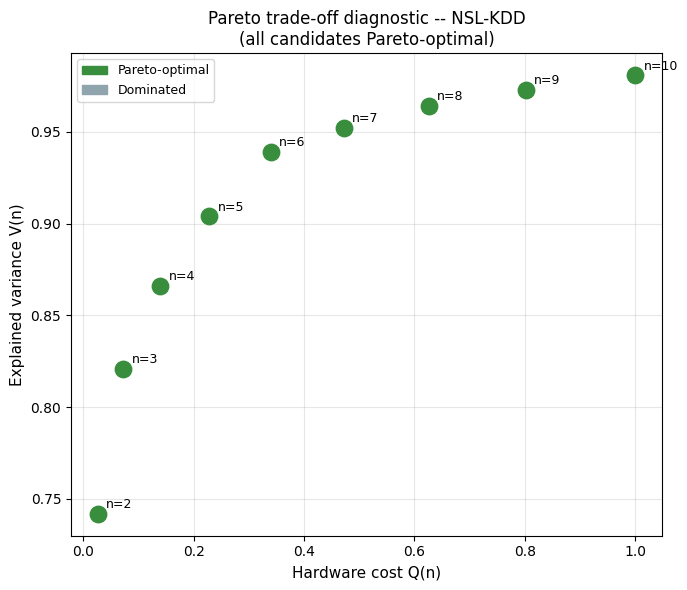

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
for r in results_all:
    is_pareto = r['n'] in pareto_n
    color  = '#388E3C' if is_pareto else '#90A4AE'
    ax.scatter(r['Q_n'], r['V_n'], color=color, s=140, zorder=4)
    ax.annotate(f"n={r['n']}", (r['Q_n'], r['V_n']), textcoords='offset points', xytext=(6,4), fontsize=9)

ax.set_xlabel('Hardware cost Q(n)', fontsize=11)
ax.set_ylabel('Explained variance V(n)', fontsize=11)
ax.set_title(f'Pareto trade-off diagnostic -- {DATA_TYPE}\n'
             f'({"all candidates Pareto-optimal" if not dominated_n else str(len(dominated_n))+" dominated"})')
ax.grid(True, alpha=0.3)
legend_h = [mpatches.Patch(color='#388E3C', label='Pareto-optimal'),
            mpatches.Patch(color='#90A4AE', label='Dominated')]
ax.legend(handles=legend_h, fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/c1_fig_pareto_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Threshold sensitivity — kiểm tra `T = 85%` có phải là lựa chọn "đẹp sau khi nhìn kết quả" không

Áp dụng cùng một rule (`smallest n` với `V(n) >= T`) cho nhiều giá trị `T` khác nhau
để đánh giá độ nhạy của dimension khả thi nhỏ nhất đối với ngưỡng information retention.

`T = 85%` đã được cố định tại Section 1 **trước khi chạy notebook này**.
Bước này chỉ nhằm minh bạch hóa mối quan hệ giữa ngưỡng `T` và dimension khả thi
nhỏ nhất; nó **không được sử dụng để chọn `n*` cuối cùng**.

Rule chọn `n*` ở Block D gồm ba bước:
1. information feasibility;
2. quantum-kernel quality;
3. hardware-cost minimization.

Finite-shot robustness được đánh giá riêng và **không tham gia selection**.

In [8]:
def smallest_n_for_threshold(candidates, T):
    feasible = [r['n'] for r in candidates if r['V_n'] >= T]
    return min(feasible) if feasible else None

threshold_rows = []
for T in THRESHOLD_GRID:
    n_feas = smallest_n_for_threshold(results_all, T)
    v_feas = next(r['V_n'] for r in results_all if r['n'] == n_feas) if n_feas else None
    threshold_rows.append({'Threshold T': T, 'Smallest feasible n': n_feas,
                            'V(n) achieved': v_feas})

thr_df = pd.DataFrame(threshold_rows)
display(thr_df.style.format({'Threshold T': '{:.0%}', 'V(n) achieved': '{:.4f}'}))

print()
print('Threshold T=85% (co dinh tu truoc) -> smallest feasible n (information-only) =',
      smallest_n_for_threshold(results_all, VARIANCE_THRESHOLD))
print('Day la information-retention constraint. Rule chon n* cuoi cung nam o Block D (Section 11),')
print('ket hop them kernel-quality (Block B) va noise robustness (Block C).')


,Threshold T,Smallest feasible n,V(n) achieved
0,80%,3,0.8210
1,85%,4,0.8662
2,90%,5,0.9040
3,95%,7,0.9524



Threshold T=85% (co dinh tu truoc) -> smallest feasible n (information-only) = 4
Day la information-retention constraint. Rule chon n* cuoi cung nam o Block D (Section 11),
ket hop them kernel-quality (Block B) va noise robustness (Block C).


## 7. Weight-sensitivity analysis (supplementary, không dùng để chọn `n`)

Đây là một phân tích **phụ trợ**, tách biệt hoàn toàn khỏi rule chính ở Block D. Mục đích: kiểm
tra xem nếu dùng một scalarized objective `J(n) = αV(n) + βFe(n) − γQ(n)` và sweep toàn bộ trọng
số trên simplex, thì các `n` khác nhau xuất hiện với tần suất bao nhiêu — **không dùng frequency
của một `n` cụ thể để claim optimum.**

In [9]:
def argmax_J(candidates, alpha, beta, gamma):
    scores = [alpha * r['V_n'] + beta * r['Fe_n'] - gamma * r['Q_n'] for r in candidates]
    return candidates[int(np.argmax(scores))]['n']

grid_pts = simplex_grid(GRID_RESOLUTION)
sensitivity_log = []
for alpha, beta, gamma in grid_pts:
    n_star_w = argmax_J(results_all, alpha, beta, gamma)
    sensitivity_log.append({'alpha': alpha, 'beta': beta, 'gamma': gamma, 'n_star': n_star_w})

sens_df = pd.DataFrame(sensitivity_log)
freq = sens_df['n_star'].value_counts(normalize=True).sort_index() * 100

print(f'Weight sensitivity sweep: {len(grid_pts)} simplex points (resolution={GRID_RESOLUTION})')
print()
print(f'{"n":>4} | {"Frequency selected":>20}')
print('-' * 28)
for n_val in ALL_N:
    pct = freq.get(n_val, 0.0)
    print(f'{n_val:>4} | {pct:>19.1f}%')

print()
print('>>> Day la mot sensitivity report, KHONG phai selection mechanism.')
print('    Rebuttal note: "We found that scalarized selection was weight-sensitive and therefore')
print('    no longer use weighted scalarization as the sole mechanism for choosing n."')


Weight sensitivity sweep: 496 simplex points (resolution=30)

   n |   Frequency selected
----------------------------
   2 |                76.0%
   3 |                 5.6%
   4 |                 3.6%
   5 |                 2.0%
   6 |                 6.7%
   7 |                 1.2%
   8 |                 1.0%
   9 |                 0.6%
  10 |                 3.2%

>>> Day la mot sensitivity report, KHONG phai selection mechanism.
    Rebuttal note: "We found that scalarized selection was weight-sensitive and therefore
    no longer use weighted scalarization as the sole mechanism for choosing n."


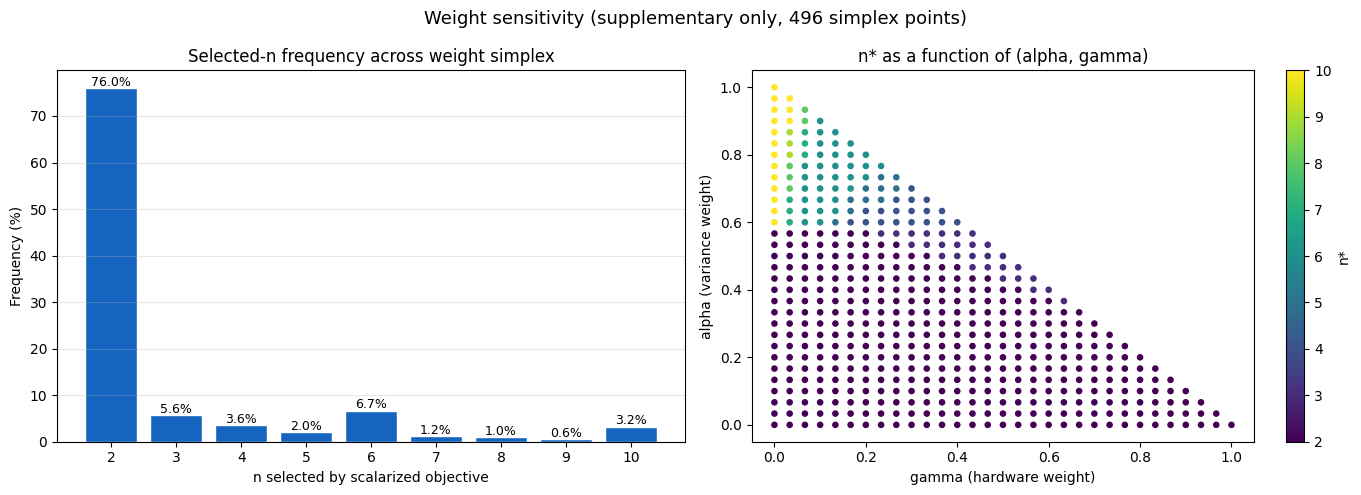

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Weight sensitivity (supplementary only, {len(grid_pts)} simplex points)', fontsize=13)

ax1 = axes[0]
ax1.bar(freq.index.astype(str), freq.values, color='#1565C0', edgecolor='white')
ax1.set_xlabel('n selected by scalarized objective'); ax1.set_ylabel('Frequency (%)')
ax1.set_title('Selected-n frequency across weight simplex')
ax1.grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(freq.items()):
    ax1.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

ax2 = axes[1]
sc = ax2.scatter(sens_df['gamma'], sens_df['alpha'], c=sens_df['n_star'], cmap='viridis', s=14)
ax2.set_xlabel('gamma (hardware weight)'); ax2.set_ylabel('alpha (variance weight)')
ax2.set_title('n* as a function of (alpha, gamma)')
plt.colorbar(sc, ax=ax2, label='n*')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/c1_fig_weight_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


# Block B — Quantum-kernel geometry

Block A chỉ đo geometry **gián tiếp** qua PCA/DBI trên không gian cổ điển. Block B đo geometry
**trực tiếp trên quantum Gram matrix** thật (ZZFeatureMap, statevector fidelity), theo đúng
Definition 2 / Eq. (1) trong manuscript.

Không tính full Gram matrix cho toàn bộ dataset (quá tốn) — chỉ dùng một **representative
subset cố định**, stratified theo `attack_category` (Normal/DoS/Probe/R2L/U2R), **cùng subset
và cùng seed cho mọi `n`** để so sánh giữa các `n` là paired/fair.

## 8. Stratified kernel-evaluation subset (cố định cho mọi `n`)

In [11]:
try:
    from qiskit.circuit.library import ZZFeatureMap
    from qiskit_machine_learning.kernels import FidelityStatevectorKernel, FidelityQuantumKernel
    QISKIT_OK = True
    print('Qiskit / Qiskit Machine Learning: OK')
except ImportError as e:
    QISKIT_OK = False
    print(f'[WARN] Khong import duoc Qiskit Machine Learning: {e}')

# Final C1 KHONG duoc phep chay ma thieu quantum-kernel-quality analysis: neu thieu Qiskit,
# dung lai ngay thay vi am tham fallback ve rule chi-information.
# Finite-shot analysis la validation rieng, khong phai selection criterion.
if not QISKIT_OK:
    raise RuntimeError(
        "Final C1 requires Qiskit/Qiskit ML. "
        "Do not produce a final selection without quantum-kernel-quality analysis."
    )


def stratified_kernel_subset(df, n_total, seed):
    """
    Chon 1 subset co dinh, stratified theo attack_category (hoac label_binary neu thieu cot,
    hoac neu mot category qua hiem de stratify duoc), dung CHUNG cho moi n trong Block B/C --
    de comparison giua n la paired/fair.
    """
    idx_all = np.arange(len(df))
    strat_col = 'attack_category' if 'attack_category' in df.columns else 'label_binary'
    try:
        idx_subset, _ = train_test_split(
            idx_all, train_size=n_total, stratify=df[strat_col].to_numpy(), random_state=seed,
        )
    except ValueError:
        # Fallback: mot category qua hiem (< 2 mau) de stratify theo attack_category -- dung label_binary.
        print(f'[WARN] Stratify theo \'{strat_col}\' that bai (category qua hiem) -- fallback ve label_binary.')
        idx_subset, _ = train_test_split(
            idx_all, train_size=n_total, stratify=df['label_binary'].to_numpy(), random_state=seed,
        )
    return np.sort(idx_subset)


kernel_idx = stratified_kernel_subset(train_df, N_KERNEL_SUBSET, KERNEL_SEED)

X_kernel_raw = X_train_raw[kernel_idx]                 # K=20 features, TRUOC PCA
y_kernel     = y_train[kernel_idx]

if 'attack_category' in train_df.columns:
    cat_kernel = train_df['attack_category'].to_numpy()[kernel_idx]
    print(f'Kernel-evaluation subset: N={len(kernel_idx)}  (seed={KERNEL_SEED}, stratified theo attack_category)')
    cats, cnts = np.unique(cat_kernel, return_counts=True)
    for c, n_c in zip(cats, cnts):
        print(f'  {c:<8}: {n_c:>4}  ({n_c/len(kernel_idx):.1%})')
else:
    print(f'Kernel-evaluation subset: N={len(kernel_idx)}  (seed={KERNEL_SEED}, stratified theo label_binary)')

u, c = np.unique(y_kernel, return_counts=True)
print('\nPhan bo label_binary trong subset:')
for ui, ci in zip(u, c):
    print(f'  {ui} : {ci}  ({ci/len(y_kernel):.1%})')

print('\n>>> QUAN TRONG: cung mot kernel_idx (= cung subset, cung seed) duoc dung cho MOI n o Block B/C.')


Qiskit / Qiskit Machine Learning: OK
Kernel-evaluation subset: N=300  (seed=42, stratified theo attack_category)
  DoS     :  109  (36.3%)
  Normal  :  161  (53.7%)
  Probe   :   28  (9.3%)
  R2L     :    2  (0.7%)

Phan bo label_binary trong subset:
  0 : 161  (53.7%)
  1 : 139  (46.3%)

>>> QUAN TRONG: cung mot kernel_idx (= cung subset, cung seed) duoc dung cho MOI n o Block B/C.


## 9. Ideal quantum Gram matrix theo `n`: `KTA(n)`, `effective rank(n)`, `concentration(n)`

Metric:

- **Primary — KTA(n)**: Kernel Target Alignment, Eq. (8) trong manuscript,
  $\mathrm{KTA}(K, y) = \dfrac{\langle K, yy^\top\rangle_F}{\|K\|_F \|yy^\top\|_F}$.
- **Diagnostic — effective rank(n)**: $R_{\mathrm{eff}} = \exp\!\big(H(\mathbf{p})\big)$ với
  $\mathbf{p}$ là phân bố eigenvalue chuẩn hoá của Gram matrix và `H` là Shannon entropy — đo
  Gram matrix "trải" trên bao nhiêu eigen-directions một cách hiệu quả (liên hệ trực tiếp tới
  cảnh báo exponential concentration của [22] trong manuscript).
- **Diagnostic — kernel concentration(n)**: mean/std của các phần tử off-diagonal — khi `n` tăng,
  nếu kernel "collapse" về một hằng số (exponential concentration), `std` off-diagonal sẽ giảm
  mạnh.

In [12]:
def kernel_target_alignment(K, y):
    """KTA(K, y), uncentred -- Eq. (8) trong manuscript."""
    y_pm = np.where(y == 0, -1.0, 1.0)
    yy = np.outer(y_pm, y_pm)
    den = np.linalg.norm(K, 'fro') * np.linalg.norm(yy, 'fro')
    return float(np.sum(K * yy) / den) if den > 0 else 0.0


def effective_rank(K):
    """R_eff = exp(Shannon entropy cua phan bo eigenvalue chuan hoa) -- day la mot kernel-geometry /
    effective-rank diagnostic, KHONG dong nhat truc tiep voi circuit expressibility (xem review section 8)."""
    eigvals = np.linalg.eigvalsh(K)
    eigvals = np.clip(eigvals, 0, None)
    s = eigvals.sum()
    if s <= 0:
        return 0.0
    p = eigvals / s
    p = p[p > 1e-12]
    entropy = -np.sum(p * np.log(p))
    return float(np.exp(entropy))


def kernel_concentration(K):
    """Mean/std cua off-diagonal entries -- concentration diagnostic (Thanasilp et al. 2024)."""
    n = K.shape[0]
    off = K[~np.eye(n, dtype=bool)]
    return float(off.mean()), float(off.std())


def frobenius_similarity(A, B):
    den = np.linalg.norm(A, 'fro') * np.linalg.norm(B, 'fro')
    return float(np.sum(A * B) / den) if den > 0 else 0.0


kernel_geometry_rows = []
gram_ideal_cache  = {}
angles_kernel_cache = {}   # cache X_kernel_angles(n) -- dung lai o Block C

if QISKIT_OK:
    print(f'{"n":>4} | {"KTA":>8} | {"R_eff":>8} | {"offdiag_mean":>13} | {"offdiag_std":>12}')
    print('-' * 58)
    for n in ALL_N:
        row_n    = next(r for r in results_all if r['n'] == n)
        pca_n    = row_n['pca_obj']       # PCA fit tren FULL TRAIN o Block A -- transform only o day
        scaler_n = row_n['scaler_obj']    # Scaler fit tren FULL TRAIN o Block A -- transform only o day
                                           # (KHONG duoc fit lai tren 300-sample kernel subset -- day la
                                           # loi scaler-leakage cua ban v3 truoc, xem review section 1:
                                           # pipeline that cua QSVM la PCA/scaler fit tren full train roi
                                           # transform test/subset, khong fit rieng tren subset)
        X_kernel_pca    = pca_n.transform(X_kernel_raw)
        X_kernel_angles = scaler_n.transform(X_kernel_pca)
        angles_kernel_cache[n] = X_kernel_angles

        fmap   = ZZFeatureMap(feature_dimension=n, reps=REPS, entanglement='full')
        kernel = FidelityStatevectorKernel(feature_map=fmap)
        K_ideal = kernel.evaluate(x_vec=X_kernel_angles)
        gram_ideal_cache[n] = K_ideal

        kta_n  = kernel_target_alignment(K_ideal, y_kernel)
        reff_n = effective_rank(K_ideal)
        mean_off, std_off = kernel_concentration(K_ideal)

        kernel_geometry_rows.append({
            'n': n, 'KTA': kta_n, 'effective_rank': reff_n,
            'offdiag_mean': mean_off, 'offdiag_std': std_off,
        })
        print(f'{n:>4} | {kta_n:>8.4f} | {reff_n:>8.2f} | {mean_off:>13.4f} | {std_off:>12.4f}')

    kernel_geom_df = pd.DataFrame(kernel_geometry_rows)

    feasible_info_for_kta = sorted(
        r['n'] for r in results_all
        if r['V_n'] >= VARIANCE_THRESHOLD
    )
    if not feasible_info_for_kta:
        raise RuntimeError(
            f'Khong co n nao dat V(n) >= {VARIANCE_THRESHOLD:.0%} trong ALL_N={ALL_N}'
        )

    kernel_feasible_df_for_kta = kernel_geom_df[
        kernel_geom_df['n'].isin(feasible_info_for_kta)
    ].copy()
    KTA_MAX_FEASIBLE = float(kernel_feasible_df_for_kta['KTA'].max())
    KTA_MAX_FEASIBLE_N = int(
        kernel_feasible_df_for_kta.loc[
            kernel_feasible_df_for_kta['KTA'].idxmax(), 'n'
        ]
    )
    KTA_THRESHOLD = (1 - KTA_TOLERANCE) * KTA_MAX_FEASIBLE
    print(f'\n>>> Information-feasible n = {feasible_info_for_kta}')
    print(f'>>> KTA_max within V>={VARIANCE_THRESHOLD:.0%} = {KTA_MAX_FEASIBLE:.4f} tai n = {KTA_MAX_FEASIBLE_N}')
    print(f'>>> KTA threshold = {KTA_THRESHOLD:.4f}')
else:
    raise RuntimeError(
        'C1 final requires Qiskit/Qiskit Machine Learning because quantum-kernel quality '
        'is part of the selection rule.'
    )


   n |      KTA |    R_eff |  offdiag_mean |  offdiag_std
----------------------------------------------------------
   2 |   0.3297 |     5.78 |        0.3464 |       0.3264
   3 |   0.1537 |     9.55 |        0.3365 |       0.2946
   4 |   0.2364 |    28.49 |        0.1476 |       0.2210
   5 |   0.2439 |    46.50 |        0.0841 |       0.1954
   6 |   0.2381 |    56.93 |        0.0628 |       0.1825
   7 |   0.1949 |    79.57 |        0.0415 |       0.1515
   8 |   0.1952 |    88.70 |        0.0334 |       0.1455
   9 |   0.1907 |   100.60 |        0.0290 |       0.1394
  10 |   0.1793 |   114.70 |        0.0248 |       0.1307

>>> Information-feasible n = [4, 5, 6, 7, 8, 9, 10]
>>> KTA_max within V>=85% = 0.2439 tai n = 5
>>> KTA threshold = 0.2317


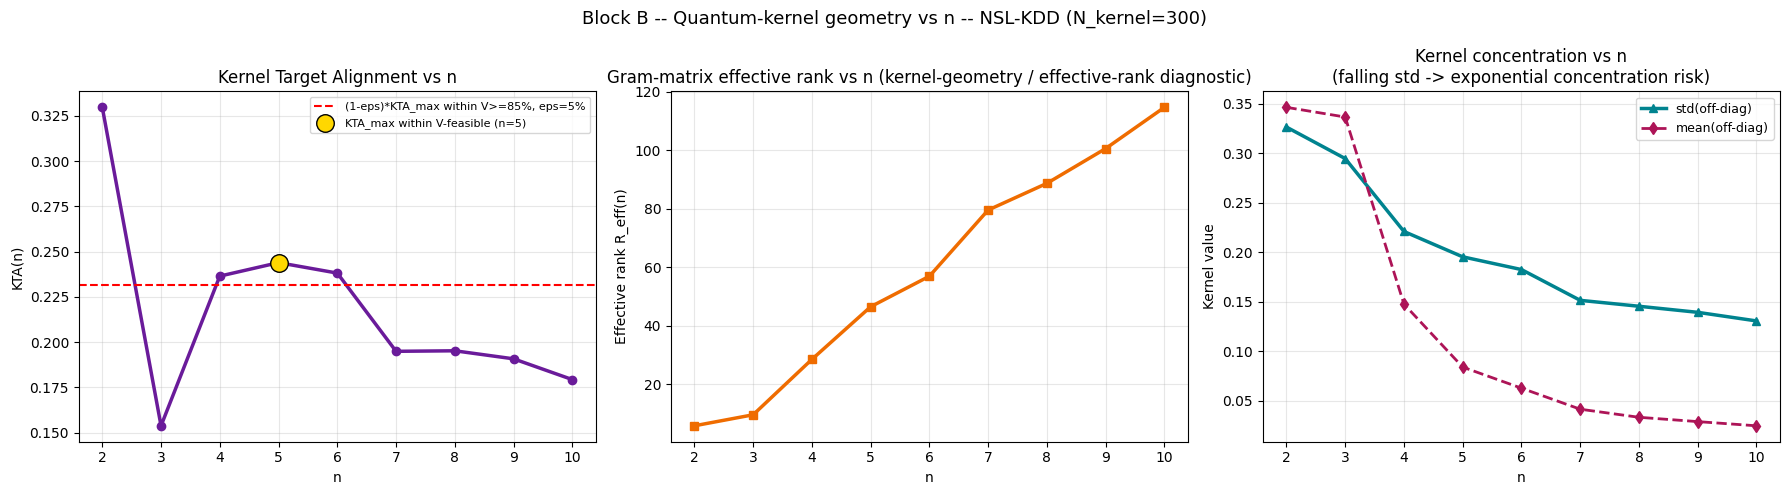

,n,KTA,effective_rank,offdiag_mean,offdiag_std
0,2,0.3297,5.78,0.3464,0.3264
1,3,0.1537,9.55,0.3365,0.2946
2,4,0.2364,28.49,0.1476,0.2210
3,5,0.2439,46.50,0.0841,0.1954
4,6,0.2381,56.93,0.0628,0.1825
5,7,0.1949,79.57,0.0415,0.1515
6,8,0.1952,88.70,0.0334,0.1455
7,9,0.1907,100.60,0.0290,0.1394
8,10,0.1793,114.70,0.0248,0.1307


In [13]:
if QISKIT_OK:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Block B -- Quantum-kernel geometry vs n -- {DATA_TYPE} (N_kernel={N_KERNEL_SUBSET})', fontsize=13)

    ax = axes[0]
    ax.plot(kernel_geom_df['n'], kernel_geom_df['KTA'], 'o-', color='#6A1B9A', linewidth=2.5)
    ax.axhline(KTA_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
               label=f'(1-eps)*KTA_max within V>={VARIANCE_THRESHOLD:.0%}, eps={KTA_TOLERANCE:.0%}')
    ax.scatter([KTA_MAX_FEASIBLE_N], [KTA_MAX_FEASIBLE], color='gold', s=160, zorder=5, edgecolor='black', label=f'KTA_max within V-feasible (n={KTA_MAX_FEASIBLE_N})')
    ax.set_xlabel('n'); ax.set_ylabel('KTA(n)'); ax.set_title('Kernel Target Alignment vs n')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(kernel_geom_df['n'], kernel_geom_df['effective_rank'], 's-', color='#EF6C00', linewidth=2.5)
    ax2.set_xlabel('n'); ax2.set_ylabel('Effective rank R_eff(n)')
    ax2.set_title('Gram-matrix effective rank vs n (kernel-geometry / effective-rank diagnostic)')
    ax2.grid(True, alpha=0.3)

    ax3 = axes[2]
    ax3.plot(kernel_geom_df['n'], kernel_geom_df['offdiag_std'], '^-', color='#00838F', linewidth=2.5,
             label='std(off-diag)')
    ax3.plot(kernel_geom_df['n'], kernel_geom_df['offdiag_mean'], 'd--', color='#AD1457', linewidth=2,
             label='mean(off-diag)')
    ax3.set_xlabel('n'); ax3.set_ylabel('Kernel value')
    ax3.set_title('Kernel concentration vs n\n(falling std -> exponential concentration risk)')
    ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/c1_kernel_quality.png', dpi=150, bbox_inches='tight')
    plt.show()

    display(kernel_geom_df.style.format({
        'KTA': '{:.4f}', 'effective_rank': '{:.2f}', 'offdiag_mean': '{:.4f}', 'offdiag_std': '{:.4f}',
    }))


## 9b. Bootstrap uncertainty cho KTA(n) (strongly recommended, review section 15)

`KTA(n)` ở Section 9 là một single point-estimate trên 300 mẫu. Nếu `n=4` và `n=5` (hoặc bất kỳ
cặp `n` liền kề nào quanh ngưỡng `(1-eps)*KTA_max`) cách nhau rất ít, criterion "trong vòng 5%"
có thể rất nhạy với sampling. Ở đây bootstrap lại **subset đã cố định** (resample có hoàn lại các
hàng/cột của Gram matrix `K_ideal(n)` đã tính sẵn — không cần chạy lại quantum kernel, nên rất
rẻ) để có khoảng tin cậy cho `KTA(n)`.


Bootstrap KTA CI: B=200 resamples cua kernel subset (N=300), seed=42, alpha=5%
   n | KTA (point) |  boot mean |               95% CI
--------------------------------------------------------
   2 |      0.3297 |     0.3360 | [0.2861, 0.3903]
   3 |      0.1537 |     0.1598 | [0.1323, 0.1822]
   4 |      0.2364 |     0.2440 | [0.2119, 0.2762]
   5 |      0.2439 |     0.2511 | [0.2224, 0.2801]
   6 |      0.2381 |     0.2453 | [0.2224, 0.2685]
   7 |      0.1949 |     0.2037 | [0.1851, 0.2209]
   8 |      0.1952 |     0.2041 | [0.1848, 0.2220]
   9 |      0.1907 |     0.1996 | [0.1799, 0.2183]
  10 |      0.1793 |     0.1888 | [0.1696, 0.2080]


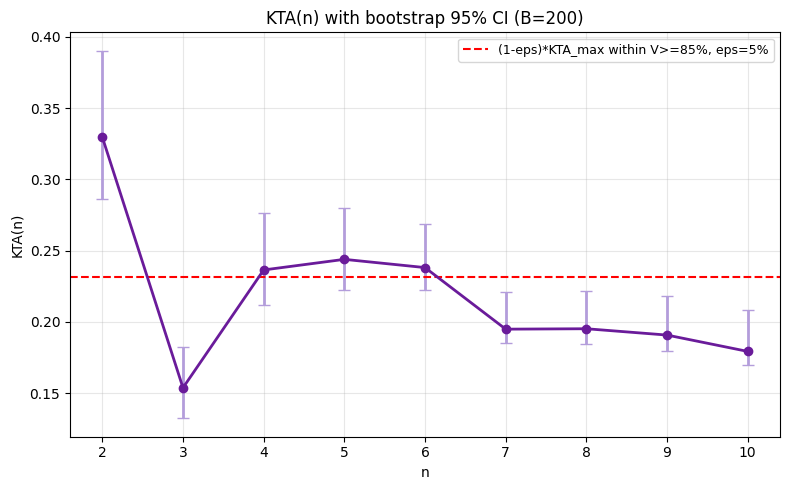

,n,KTA,boot_mean,ci_low,ci_high
0,2,0.3297,0.3360,0.2861,0.3903
1,3,0.1537,0.1598,0.1323,0.1822
2,4,0.2364,0.2440,0.2119,0.2762
3,5,0.2439,0.2511,0.2224,0.2801
4,6,0.2381,0.2453,0.2224,0.2685
5,7,0.1949,0.2037,0.1851,0.2209
6,8,0.1952,0.2041,0.1848,0.2220
7,9,0.1907,0.1996,0.1799,0.2183
8,10,0.1793,0.1888,0.1696,0.2080


In [14]:
N_BOOTSTRAP     = 200
BOOTSTRAP_SEED  = GLOBAL_SEED
BOOTSTRAP_ALPHA = 0.05   # 95% CI

def bootstrap_kta_ci(K, y, B=200, seed=42, alpha=0.05):
    """Bootstrap CI cho KTA bang cach resample (co hoan lai) cac chi so mau cua Gram matrix
    da tinh san -- KHONG can chay lai quantum kernel, chi index lai K va y."""
    rng = np.random.default_rng(seed)
    n_samples = K.shape[0]
    boot_ktas = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n_samples, size=n_samples)
        K_boot = K[np.ix_(idx, idx)]
        y_boot = y[idx]
        boot_ktas[b] = kernel_target_alignment(K_boot, y_boot)
    lo = float(np.percentile(boot_ktas, 100 * alpha / 2))
    hi = float(np.percentile(boot_ktas, 100 * (1 - alpha / 2)))
    return float(boot_ktas.mean()), lo, hi, boot_ktas

kta_ci_rows = []
if QISKIT_OK:
    print(f'Bootstrap KTA CI: B={N_BOOTSTRAP} resamples cua kernel subset (N={N_KERNEL_SUBSET}), '
          f'seed={BOOTSTRAP_SEED}, alpha={BOOTSTRAP_ALPHA:.0%}')
    print(f'{"n":>4} | {"KTA (point)":>11} | {"boot mean":>10} | {"95% CI":>20}')
    print('-' * 56)
    for n in ALL_N:
        K_ideal_n = gram_ideal_cache[n]
        boot_mean, ci_lo, ci_hi, _ = bootstrap_kta_ci(
            K_ideal_n, y_kernel, B=N_BOOTSTRAP, seed=BOOTSTRAP_SEED, alpha=BOOTSTRAP_ALPHA,
        )
        kta_point = next(r['KTA'] for r in kernel_geometry_rows if r['n'] == n)
        kta_ci_rows.append({
            'n': n, 'KTA': kta_point, 'boot_mean': boot_mean,
            'ci_low': ci_lo, 'ci_high': ci_hi,
        })
        print(f'{n:>4} | {kta_point:>11.4f} | {boot_mean:>10.4f} | [{ci_lo:.4f}, {ci_hi:.4f}]')

    kta_ci_df = pd.DataFrame(kta_ci_rows)

    # Canh bao neu CI cua candidate lien ke n* (SELECTED_N se duoc tinh o Block D, chua co o day --
    # danh dau tam thoi de doi chieu sau khi Block D chay xong) trung lap dang ke.
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        kta_ci_df['n'], kta_ci_df['KTA'],
        yerr=[kta_ci_df['KTA'] - kta_ci_df['ci_low'], kta_ci_df['ci_high'] - kta_ci_df['KTA']],
        fmt='o-', color='#6A1B9A', ecolor='#B39DDB', elinewidth=2, capsize=4, linewidth=2,
    )
    ax.axhline(KTA_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
               label=f'(1-eps)*KTA_max within V>={VARIANCE_THRESHOLD:.0%}, eps={KTA_TOLERANCE:.0%}')
    ax.set_xlabel('n'); ax.set_ylabel('KTA(n)')
    ax.set_title(f'KTA(n) with bootstrap 95% CI (B={N_BOOTSTRAP})')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/c1_kta_bootstrap_ci.png', dpi=150, bbox_inches='tight')
    plt.show()

    display(kta_ci_df.style.format({
        'KTA': '{:.4f}', 'boot_mean': '{:.4f}', 'ci_low': '{:.4f}', 'ci_high': '{:.4f}',
    }))
else:
    kta_ci_df = None
    print('[SKIP] Qiskit khong san sang -- bootstrap CI khong chay.')


# Block C — Finite-Shot Robustness Validation

Block C không tham gia vào việc chọn embedding dimension.

Mục tiêu của block này là kiểm tra liệu việc ước lượng quantum kernel bằng một finite measurement budget có làm biến dạng đáng kể Gram matrix hay không.

Chúng tôi so sánh:

- ideal statevector quantum kernel;
- finite-shot quantum kernel.

Các metric:

$$
D_{\text{noise}}(n)
=
1-\operatorname{FroSim}(K_{\text{ideal}},K_{\text{noisy}})
$$

và:

$$
\Delta KTA(n)
=
KTA_{\text{noisy}}(n)-KTA_{\text{ideal}}(n).
$$

Đây là finite-shot sampling analysis, không phải realistic gate-level hardware-noise simulation.


## 10. Finite-shot noisy Gram matrix theo `n`

In [15]:
noise_rows = []
gram_noisy_cache = {}

if QISKIT_OK:
    try:
        from qiskit_machine_learning.state_fidelities import ComputeUncompute
    except ImportError:
        from qiskit_algorithms.state_fidelities import ComputeUncompute
    from qiskit.primitives import StatevectorSampler

    print(f'Finite-shot noisy simulation: shots={NOISE_SHOTS}, seed={NOISE_SEED}')
    print(f'{"n":>4} | {"FroSim":>8} | {"D_noise":>8} | {"KTA_noisy":>10} | {"delta_KTA":>10}')
    print('-' * 54)

    for n in ALL_N:
        X_kernel_angles = angles_kernel_cache[n]

        fmap = ZZFeatureMap(feature_dimension=n, reps=REPS, entanglement='full')
        sampler  = StatevectorSampler(default_shots=NOISE_SHOTS, seed=NOISE_SEED)
        fidelity = ComputeUncompute(sampler=sampler)
        noisy_kernel = FidelityQuantumKernel(feature_map=fmap, fidelity=fidelity)

        K_noisy = noisy_kernel.evaluate(x_vec=X_kernel_angles)
        gram_noisy_cache[n] = K_noisy

        K_ideal   = gram_ideal_cache[n]
        fro_sim   = frobenius_similarity(K_ideal, K_noisy)
        d_noise   = 1.0 - fro_sim
        kta_noisy = kernel_target_alignment(K_noisy, y_kernel)
        kta_ideal = next(r['KTA'] for r in kernel_geometry_rows if r['n'] == n)
        delta_kta = kta_noisy - kta_ideal

        noise_rows.append({
            'n': n, 'FroSim': fro_sim, 'D_noise': d_noise,
            'KTA_noisy': kta_noisy, 'delta_KTA': delta_kta,
        })
        print(f'{n:>4} | {fro_sim:>8.4f} | {d_noise:>8.4f} | {kta_noisy:>10.4f} | {delta_kta:>+10.4f}')

    noise_df = pd.DataFrame(noise_rows)
else:
    noise_df = None
    print('[SKIP] Qiskit khong san sang -- Block C khong chay.')


Finite-shot noisy simulation: shots=1024, seed=42
   n |   FroSim |  D_noise |  KTA_noisy |  delta_KTA
------------------------------------------------------
   2 |   0.9999 |   0.0001 |     0.3283 |    -0.0014
   3 |   0.9999 |   0.0001 |     0.1527 |    -0.0011
   4 |   0.9997 |   0.0003 |     0.2340 |    -0.0024
   5 |   0.9999 |   0.0001 |     0.2440 |    +0.0002
   6 |   0.9999 |   0.0001 |     0.2388 |    +0.0007
   7 |   0.9999 |   0.0001 |     0.1957 |    +0.0008
   8 |   1.0000 |   0.0000 |     0.1956 |    +0.0004
   9 |   1.0000 |   0.0000 |     0.1913 |    +0.0005
  10 |   1.0000 |   0.0000 |     0.1799 |    +0.0007


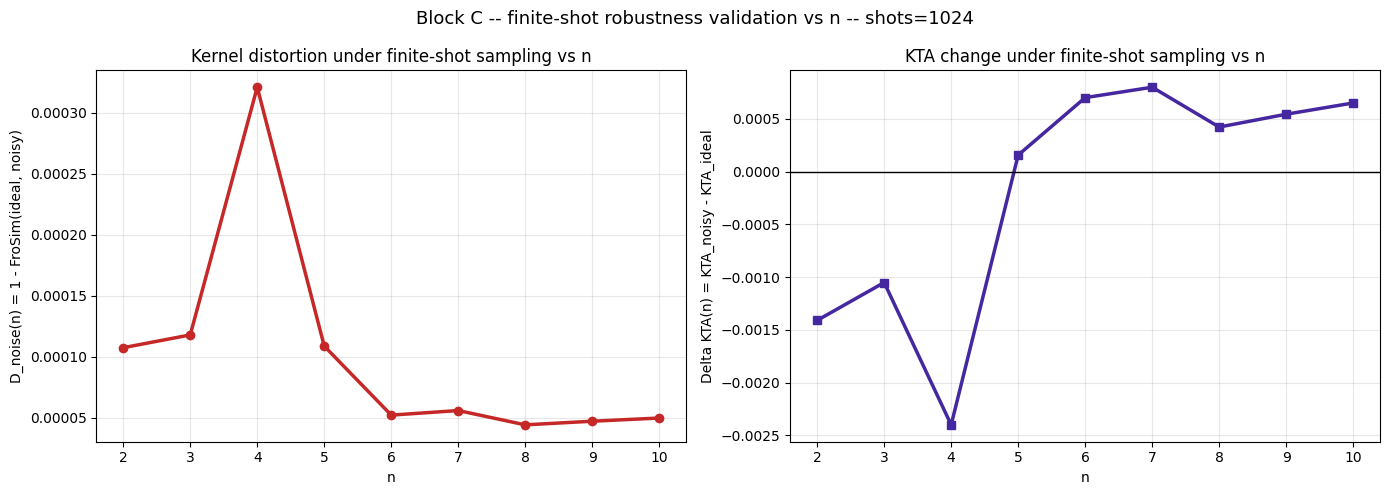

,n,FroSim,D_noise,KTA_noisy,delta_KTA
0,2,0.9999,0.0001,0.3283,-0.0014
1,3,0.9999,0.0001,0.1527,-0.0011
2,4,0.9997,0.0003,0.2340,-0.0024
3,5,0.9999,0.0001,0.2440,+0.0002
4,6,0.9999,0.0001,0.2388,+0.0007
5,7,0.9999,0.0001,0.1957,+0.0008
6,8,1.0000,0.0000,0.1956,+0.0004
7,9,1.0000,0.0000,0.1913,+0.0005
8,10,1.0000,0.0000,0.1799,+0.0007



Doc bieu do: D_noise(n) va delta_KTA(n) la validation rieng cho finite-shot sampling.
Cac metric nay kiem tra do on dinh cua Gram matrix, nhung KHONG tham gia selection rule.


In [16]:
if QISKIT_OK:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Block C -- finite-shot robustness validation vs n -- shots={NOISE_SHOTS}', fontsize=13)

    ax = axes[0]
    ax.plot(noise_df['n'], noise_df['D_noise'], 'o-', color='#C62828', linewidth=2.5)
    ax.set_xlabel('n'); ax.set_ylabel('D_noise(n) = 1 - FroSim(ideal, noisy)')
    ax.set_title('Kernel distortion under finite-shot sampling vs n')
    ax.grid(True, alpha=0.3)

    ax2 = axes[1]
    ax2.plot(noise_df['n'], noise_df['delta_KTA'], 's-', color='#4527A0', linewidth=2.5)
    ax2.axhline(0, color='black', linewidth=1)
    ax2.set_xlabel('n'); ax2.set_ylabel('Delta KTA(n) = KTA_noisy - KTA_ideal')
    ax2.set_title('KTA change under finite-shot sampling vs n')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/c1_noise_robustness.png', dpi=150, bbox_inches='tight')
    plt.show()

    display(noise_df.style.format({
        'FroSim': '{:.4f}', 'D_noise': '{:.4f}', 'KTA_noisy': '{:.4f}', 'delta_KTA': '{:+.4f}',
    }))

    print()
    print('Doc bieu do: D_noise(n) va delta_KTA(n) la validation rieng cho finite-shot sampling.')
    print('Cac metric nay kiem tra do on dinh cua Gram matrix, nhung KHONG tham gia selection rule.')


## 10b. Shot sensitivity: `shots in {256, 512, 1024}` trên dimension đại diện

Sensitivity analysis uses representative low, middle, and high embedding dimensions to verify that the observed finite-shot behavior is not tied to the 1024-shot operating point.

Cấu hình giữ cố định:

```python
NOISE_SHOTS = 1024
SHOTS_GRID = [256, 512, 1024]
SHOT_SENS_N = [4, 6, 10]
```

Các giá trị `shots=1024` được tái sử dụng trực tiếp từ Block C chính, nên phần này chỉ cần thêm 6 finite-shot evaluations thay vì quét lại toàn bộ `ALL_N`.


Shot sensitivity sweep (reduced): shots in [256, 512, 1024], n in [4, 6, 10]
 shots |    n |  D_noise |    source
------------------------------------
   256 |    4 |   0.0007 |  computed
   512 |    4 |   0.0008 |  computed
  1024 |    4 |   0.0003 |    reused
   256 |    6 |   0.0005 |  computed
   512 |    6 |   0.0006 |  computed
  1024 |    6 |   0.0001 |    reused
   256 |   10 |   0.0003 |  computed
   512 |   10 |   0.0002 |  computed
  1024 |   10 |   0.0000 |    reused

>>> Kernel evaluations moi trong sensitivity sweep nay: 6 (cac gia tri shots=1024 duoc tai su dung tu Section 10, khong tinh lai)


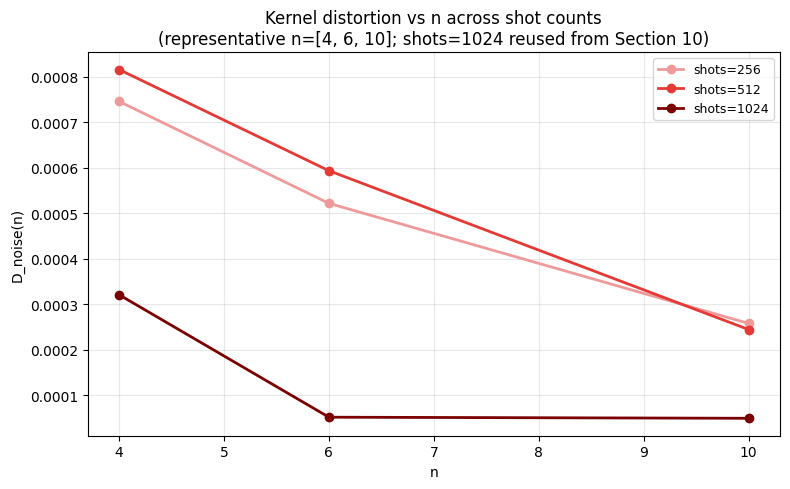

shots,256,512,1024
n,,,
4,0.0007,0.0008,0.0003
6,0.0005,0.0006,0.0001
10,0.0003,0.0002,0.0000



>>> Trend D_noise(n) KHONG nhat quan giua cac muc shots (tren n dai dien) -- can bao cao
    trung thuc va than trong khi generalize hoa ket luan ve noise-sensitivity trong manuscript.

Wording de xuat cho manuscript/supplementary:
  "The observed finite-shot distortion trend was checked at representative low, selected,
   and high embedding dimensions (n=[4, 6, 10]) across shots in [256, 512, 1024]; the
   shots=1024 values reuse the main finite-shot evaluation (Section 10) rather
   than being recomputed."


In [17]:
SHOTS_GRID   = [256, 512, 1024]
SHOT_SENS_N  = [4, 6, 10]   # dai dien: operating point / middle / largest candidate -- khong quet toan bo ALL_N

shot_sensitivity_rows = []
if QISKIT_OK:
    try:
        from qiskit_machine_learning.state_fidelities import ComputeUncompute
    except ImportError:
        from qiskit_algorithms.state_fidelities import ComputeUncompute
    from qiskit.primitives import StatevectorSampler

    print(f'Shot sensitivity sweep (reduced): shots in {SHOTS_GRID}, n in {SHOT_SENS_N}')
    print(f'{"shots":>6} | {"n":>4} | {"D_noise":>8} | {"source":>9}')
    print('-' * 36)

    for n in SHOT_SENS_N:
        for shots in SHOTS_GRID:
            if shots == NOISE_SHOTS:
                # Tai su dung ket qua da tinh o Block C chinh (Section 10, noise_df) --
                # KHONG chay lai kernel cho shots=1024, dung dung n da co trong feasible ALL_N.
                d_noise_s = float(noise_df.loc[noise_df['n'] == n, 'D_noise'].iloc[0])
                source = 'reused'
            else:
                X_kernel_angles_n = angles_kernel_cache[n]

                fmap_s     = ZZFeatureMap(feature_dimension=n, reps=REPS, entanglement='full')
                sampler_s  = StatevectorSampler(default_shots=shots, seed=NOISE_SEED)
                fidelity_s = ComputeUncompute(sampler=sampler_s)
                noisy_kernel_s = FidelityQuantumKernel(feature_map=fmap_s, fidelity=fidelity_s)

                K_noisy_s = noisy_kernel_s.evaluate(x_vec=X_kernel_angles_n)
                K_ideal_n = gram_ideal_cache[n]
                d_noise_s = 1.0 - frobenius_similarity(K_ideal_n, K_noisy_s)
                source = 'computed'

            shot_sensitivity_rows.append({'shots': shots, 'n': n, 'D_noise': d_noise_s, 'source': source})
            print(f'{shots:>6} | {n:>4} | {d_noise_s:>8.4f} | {source:>9}')

    n_new_evals = sum(1 for r in shot_sensitivity_rows if r['source'] == 'computed')
    print(f'\n>>> Kernel evaluations moi trong sensitivity sweep nay: {n_new_evals} '
          f'(cac gia tri shots={NOISE_SHOTS} duoc tai su dung tu Section 10, khong tinh lai)')

    shot_sens_df = pd.DataFrame(shot_sensitivity_rows)
    pivot_shots  = shot_sens_df.pivot(index='n', columns='shots', values='D_noise')

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = {256: '#EF9A9A', 512: '#E53935', 1024: '#7B0000'}
    for shots in SHOTS_GRID:
        sub = shot_sens_df[shot_sens_df['shots'] == shots].sort_values('n')
        ax.plot(sub['n'], sub['D_noise'], 'o-', color=colors.get(shots, None),
                linewidth=2, label=f'shots={shots}')
    ax.set_xlabel('n'); ax.set_ylabel('D_noise(n)')
    ax.set_title(f'Kernel distortion vs n across shot counts\n'
                 f'(representative n={SHOT_SENS_N}; shots={NOISE_SHOTS} reused from Section 10)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/c1_shot_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()

    display(pivot_shots.style.format('{:.4f}'))

    trend_consistent = all(
        shot_sens_df[shot_sens_df['shots'] == s].sort_values('n')['D_noise'].is_monotonic_increasing
        for s in SHOTS_GRID
    )
    print()
    if trend_consistent:
        print(f'>>> D_noise(n) tang don dieu theo n (tren 3 diem dai dien n={SHOT_SENS_N}) o CA BA muc shots')
        print( '    -- ket luan ve noise-sensitivity khong phu thuoc vao lua chon NOISE_SHOTS=1024 cu the.')
    else:
        print( '>>> Trend D_noise(n) KHONG nhat quan giua cac muc shots (tren n dai dien) -- can bao cao')
        print( '    trung thuc va than trong khi generalize hoa ket luan ve noise-sensitivity trong manuscript.')

    print()
    print('Wording de xuat cho manuscript/supplementary:')
    print('  "The observed finite-shot distortion trend was checked at representative low, selected,')
    print(f'   and high embedding dimensions (n={SHOT_SENS_N}) across shots in {SHOTS_GRID}; the')
    print(f'   shots={NOISE_SHOTS} values reuse the main finite-shot evaluation (Section 10) rather')
    print('   than being recomputed."')
else:
    shot_sens_df = None
    print('[SKIP] Qiskit khong san sang -- shot sensitivity sweep khong chay.')


# Block D — Hardware-Aware Embedding-Dimension Selection

C1 không sử dụng một objective scalarized nhiều chiều để trộn tất cả metrics thành một score duy nhất. Thay vào đó, selection được xây dựng theo thứ tự ba bước có ý nghĩa rõ ràng:

### Step 1 — Information feasibility

Chỉ giữ các embedding dimension thỏa:

$$
V(n) \ge 0.85.
$$

Điều này xác định vùng embedding có mức information retention chấp nhận được.

### Step 2 — Quantum-kernel quality feasibility

Trong **chỉ vùng information-feasible**, xác định:

$$
KTA_{\max,F_V}
=
\max_{n\in F_V} KTA(n).
$$

Một dimension được giữ lại nếu:

$$
KTA(n)
\ge
(1-\epsilon)KTA_{\max,F_V},
\qquad \epsilon=0.05.
$$

Như vậy, việc đánh giá kernel quality không bị chi phối bởi các dimension đã bị loại do không đạt yêu cầu information retention.

### Step 3 — Hardware-cost selection

Trong tập còn lại, chọn dimension có hardware-cost proxy thấp nhất:

$$
n^*
=
\arg\min_{n\in F_{V,KTA}} Q(n).
$$

We define the normalized hardware-cost proxy as

$$
Q(n)
=
\frac{N_{1q}(n)+5N_{\mathrm{CNOT}}(n)}
{Q_{\max}},
$$

where

$$
N_{1q}(n)=nr
$$

and, for the full-entanglement ZZFeatureMap,

$$
N_{\mathrm{CNOT}}(n)
=
2r\binom{n}{2}.
$$

Each pairwise ZZ interaction is implemented using a
CNOT–RZ–CNOT decomposition and therefore contributes
two CNOT gates. The factor 5 provides a relative weight
for two-qubit operations in the adopted NISQ hardware-cost
proxy.

Do đó, selection không chỉ tìm embedding có information retention cao, mà tìm điểm có kernel quality chấp nhận được với hardware-cost proxy thấp nhất, được tính từ actual (decomposed) CNOT count thay vì chỉ đếm số ZZ interaction pairs.

### Finite-shot validation

Finite-shot noise không tham gia vào selection rule. Block C chỉ kiểm tra sau/đồng thời rằng embedding được lựa chọn có giữ được quantum Gram-matrix geometry dưới measurement sampling noise trong budget shots được đánh giá.


## 11. Constraints → feasible set → `n*`

In [18]:
feasible_info = sorted(
    r['n'] for r in results_all
    if r['V_n'] >= VARIANCE_THRESHOLD
)

if not feasible_info:
    raise RuntimeError(
        f'Khong co n nao dat V(n) >= {VARIANCE_THRESHOLD:.0%} trong ALL_N={ALL_N}'
    )

if not QISKIT_OK:
    raise RuntimeError(
        'C1 final requires Qiskit/Qiskit Machine Learning because quantum-kernel quality '
        'is part of the selection rule.'
    )

kernel_feasible_df = kernel_geom_df[
    kernel_geom_df['n'].isin(feasible_info)
].copy()

KTA_MAX_FEASIBLE = float(kernel_feasible_df['KTA'].max())
KTA_MAX_FEASIBLE_N = int(
    kernel_feasible_df.loc[
        kernel_feasible_df['KTA'].idxmax(), 'n'
    ]
)
KTA_THRESHOLD = (1 - KTA_TOLERANCE) * KTA_MAX_FEASIBLE

feasible_kernel = sorted(
    kernel_feasible_df.loc[
        kernel_feasible_df['KTA'] >= KTA_THRESHOLD,
        'n'
    ].tolist()
)

feasible_final = sorted(set(feasible_info) & set(feasible_kernel))

if not feasible_final:
    raise RuntimeError(
        'Khong co n nao thoa dong thoi information va KTA constraints -- '
        'can noi long KTA_TOLERANCE hoac xem lai kernel geometry.'
    )

feasible_df = pd.DataFrame([
    {
        'n': r['n'],
        'V_n': r['V_n'],
        'Q_n': r['Q_n'],
        'KTA': float(kernel_geom_df.loc[kernel_geom_df['n'] == r['n'], 'KTA'].iloc[0]),
    }
    for r in results_all
    if r['n'] in feasible_final
])

best_idx = feasible_df['Q_n'].idxmin()
SELECTED_N = int(feasible_df.loc[best_idx, 'n'])
n_chosen = SELECTED_N
selected_row = next(r for r in results_all if r['n'] == n_chosen)

print('Constraint 1 -- Information')
print(f'V >= {VARIANCE_THRESHOLD:.0%}')
print(f'-> {feasible_info}')
print()
print('KTA maximum within information-feasible set')
print(f'-> n={KTA_MAX_FEASIBLE_N}')
print(f'-> KTA = {KTA_MAX_FEASIBLE:.4f}')
print()
print('Constraint 2 -- Kernel quality')
print(f'KTA >= {KTA_THRESHOLD:.4f}')
print(f'-> {feasible_kernel}')
print()
print('Hardware-cost selection')
for _, row in feasible_df.sort_values('n').iterrows():
    print(f'-> Q({int(row["n"])})={row["Q_n"]:.4f}')
print()
print('Selected operating point')
print(f'-> n*={n_chosen}')
print(f'   V({n_chosen})={selected_row["V_n"]:.4%}')
print(f'   KTA({n_chosen})={float(feasible_df.loc[feasible_df["n"] == n_chosen, "KTA"].iloc[0]):.4f}')
print(f'   Q({n_chosen})={selected_row["Q_n"]:.4f}')

# Validation-only cross-check: finite-shot metric trong feasible set, KHONG dung de chon n.
noise_feasible = noise_df[noise_df['n'].isin(feasible_final)]
n_min_noise = int(noise_feasible.loc[noise_feasible['D_noise'].idxmin(), 'n'])
print()
print(f'[Validation only] n co D_noise(n) thap nhat trong feasible set: {n_min_noise}')
print('Finite-shot robustness is reported separately and is not a selection criterion.')


Constraint 1 -- Information
V >= 85%
-> [4, 5, 6, 7, 8, 9, 10]

KTA maximum within information-feasible set
-> n=5
-> KTA = 0.2439

Constraint 2 -- Kernel quality
KTA >= 0.2317
-> [4, 5, 6]

Hardware-cost selection
-> Q(4)=0.1391
-> Q(5)=0.2283
-> Q(6)=0.3391

Selected operating point
-> n*=4
   V(4)=86.6187%
   KTA(4)=0.2364
   Q(4)=0.1391

[Validation only] n co D_noise(n) thap nhat trong feasible set: 6
Finite-shot robustness is reported separately and is not a selection criterion.


### 11b. KTA tolerance sensitivity: `eps in {2%, 5%, 10%}`

`KTA_TOLERANCE = 5%` là một hyperparameter được định nghĩa ở Section 1. Bảng dưới đây là sensitivity report cho selection rule mới: với mỗi `eps`, KTA reference vẫn được tính **chỉ trong vùng information-feasible**, rồi chọn `argmin Q(n)` trong tập còn lại.


In [19]:
EPSILON_GRID = [0.02, 0.05, 0.10]

eps_sensitivity_rows = []
for eps in EPSILON_GRID:
    kta_threshold_eps = (1 - eps) * KTA_MAX_FEASIBLE
    feas_kernel_eps = sorted(kernel_feasible_df.loc[
        kernel_feasible_df['KTA'] >= kta_threshold_eps, 'n'
    ].tolist())
    feas_final_eps = sorted(set(feasible_info) & set(feas_kernel_eps))
    if feas_final_eps:
        feas_df_eps = pd.DataFrame([
            {'n': r['n'], 'Q_n': r['Q_n']}
            for r in results_all
            if r['n'] in feas_final_eps
        ])
        n_star_eps = int(feas_df_eps.loc[feas_df_eps['Q_n'].idxmin(), 'n'])
    else:
        n_star_eps = None
    eps_sensitivity_rows.append({
        'epsilon'          : eps,
        'kta_threshold'    : kta_threshold_eps,
        'kernel_feasible_n': str(feas_kernel_eps),
        'final_feasible_n' : str(feas_final_eps),
        'n_star'           : n_star_eps,
    })

eps_df = pd.DataFrame(eps_sensitivity_rows)
print(f'KTA tolerance sensitivity (KTA reference: max within V(n) >= {VARIANCE_THRESHOLD:.0%}):')
print()
for row in eps_sensitivity_rows:
    print(f"  eps={row['epsilon']:.0%}  ->  threshold={row['kta_threshold']:.4f}  "
          f"-> feasible n={row['final_feasible_n']}  ->  n* = {row['n_star']}")
print()
display(eps_df.style.format({'epsilon': '{:.0%}', 'kta_threshold': '{:.4f}'}))

n_star_values = set(r['n_star'] for r in eps_sensitivity_rows)
if len(n_star_values) == 1:
    print(f'\n>>> n* on dinh (= {SELECTED_N}) tren toan bo eps in {EPSILON_GRID}.')
    print('    Sensitivity nay la supplementary diagnostic, khong dung de chon lai eps.')
else:
    print(f'\n>>> n* THAY DOI theo eps: {sorted(v for v in n_star_values if v is not None)}.')
    print('    Can bao cao ro trong manuscript/supplementary rang KTA_TOLERANCE=5% co anh huong den ket qua.')


KTA tolerance sensitivity (KTA reference: max within V(n) >= 85%):

  eps=2%  ->  threshold=0.2390  -> feasible n=[5]  ->  n* = 5
  eps=5%  ->  threshold=0.2317  -> feasible n=[4, 5, 6]  ->  n* = 4
  eps=10%  ->  threshold=0.2195  -> feasible n=[4, 5, 6]  ->  n* = 4



,epsilon,kta_threshold,kernel_feasible_n,final_feasible_n,n_star
0,2%,0.2390,[5],[5],5
1,5%,0.2317,"[4, 5, 6]","[4, 5, 6]",4
2,10%,0.2195,"[4, 5, 6]","[4, 5, 6]",4



>>> n* THAY DOI theo eps: [4, 5].
    Can bao cao ro trong manuscript/supplementary rang KTA_TOLERANCE=5% co anh huong den ket qua.


### Kiểm tra: `n=4` có còn được chọn không?

Kiểm tra này chỉ xác nhận operating point sau rule chính thức:

- information-feasible trước;
- KTA-feasible trong vùng information-feasible;
- `argmin Q(n)` trong tập còn lại.

Finite-shot validation không thể thay đổi `n*`.


In [20]:
print('=' * 72)
if n_chosen == 4:
    print('  Selected operating point remains n=4.')
else:
    print(f'  Selected operating point changed to n={n_chosen}; downstream experiments must be rerun.')
print('  Selection rule: information -> kernel quality -> CNOT-weighted hardware-cost proxy.')
print('  Finite-shot validation is reported separately and is not part of the selection criterion.')
print('=' * 72)


  Selected operating point remains n=4.
  Selection rule: information -> kernel quality -> CNOT-weighted hardware-cost proxy.
  Finite-shot validation is reported separately and is not part of the selection criterion.


## 12. Paper-ready summary — protocol C1

Ô dưới đây tổng hợp trực tiếp 4 câu hỏi chính của C1 và paper-ready narrative. Finite-shot analysis được báo cáo như validation riêng, không phải selection criterion.


In [21]:
print('=' * 78)
print('  C1 -- HARDWARE-AWARE QUANTUM EMBEDDING-DIMENSION SELECTION')
print('=' * 78)

print('\n[Q1] Khi tang n, information retention thay doi the nao?')
for r in results_all:
    print(f'     n={r["n"]}: V(n)={r["V_n"]:.2%}, Q(n)={r["Q_n"]:.4f}')
print(f'     Information-feasible set: {feasible_info}')

print('\n[Q2] Khi tang n, quantum-kernel quality thay doi the nao?')
kta_start, kta_end = kernel_geom_df.iloc[0]['KTA'], kernel_geom_df.iloc[-1]['KTA']
reff_start, reff_end = kernel_geom_df.iloc[0]['effective_rank'], kernel_geom_df.iloc[-1]['effective_rank']
print(f'     KTA: {kta_start:.4f} (n={ALL_N[0]}) -> {kta_end:.4f} (n={ALL_N[-1]})')
print(f'     KTA_max within V>={VARIANCE_THRESHOLD:.0%}: {KTA_MAX_FEASIBLE:.4f} at n={KTA_MAX_FEASIBLE_N}')
print(f'     Effective rank: {reff_start:.2f} (n={ALL_N[0]}) -> {reff_end:.2f} (n={ALL_N[-1]})')

print('\n[Q3] Khi ket hop information + KTA constraints, feasible set con gi?')
print(f'     V-feasible: {feasible_info}')
print(f'     KTA threshold: {KTA_THRESHOLD:.4f}')
print(f'     F_(V,KTA): {feasible_final}')

print('\n[Q4] Trong feasible set, hardware cost chon operating point nao?')
for _, row in feasible_df.sort_values('n').iterrows():
    print(f'     n={int(row["n"])}: Q(n)={row["Q_n"]:.4f}')
print(f'     -> n* = {SELECTED_N}')

print('\n[Finite-shot validation]')
d0, d1 = noise_df.iloc[0]['D_noise'], noise_df.iloc[-1]['D_noise']
print(f'     D_noise: {d0:.4f} (n={ALL_N[0]}) -> {d1:.4f} (n={ALL_N[-1]})  [shots={NOISE_SHOTS}]')
print(f'     delta_KTA range: [{noise_df["delta_KTA"].min():+.4f}, {noise_df["delta_KTA"].max():+.4f}]')
print('     Role: validation only, not used to select n.')

print('\n[Narrative for manuscript]')
print('  "We impose an a priori 85% cumulative-variance requirement. Among dimensions')
print('   satisfying this requirement, we evaluate quantum-kernel alignment and retain')
print('   dimensions within 5% of the best KTA in the information-feasible region.')
print(f'   This yields the feasible set {feasible_final}. We then select the minimum')
print(f'   CNOT-weighted hardware cost within this set, resulting in n={SELECTED_N}.')
print('   The selected configuration is frozen before downstream experiments.')
print('   Finite-shot analysis is reported separately as a robustness validation and')
print('   is not used as a selection criterion."')
print('=' * 78)


  C1 -- HARDWARE-AWARE QUANTUM EMBEDDING-DIMENSION SELECTION

[Q1] Khi tang n, information retention thay doi the nao?
     n=2: V(n)=74.18%, Q(n)=0.0261
     n=3: V(n)=82.10%, Q(n)=0.0717
     n=4: V(n)=86.62%, Q(n)=0.1391
     n=5: V(n)=90.40%, Q(n)=0.2283
     n=6: V(n)=93.91%, Q(n)=0.3391
     n=7: V(n)=95.24%, Q(n)=0.4717
     n=8: V(n)=96.43%, Q(n)=0.6261
     n=9: V(n)=97.29%, Q(n)=0.8022
     n=10: V(n)=98.10%, Q(n)=1.0000
     Information-feasible set: [4, 5, 6, 7, 8, 9, 10]

[Q2] Khi tang n, quantum-kernel quality thay doi the nao?
     KTA: 0.3297 (n=2) -> 0.1793 (n=10)
     KTA_max within V>=85%: 0.2439 at n=5
     Effective rank: 5.78 (n=2) -> 114.70 (n=10)

[Q3] Khi ket hop information + KTA constraints, feasible set con gi?
     V-feasible: [4, 5, 6, 7, 8, 9, 10]
     KTA threshold: 0.2317
     F_(V,KTA): [4, 5, 6]

[Q4] Trong feasible set, hardware cost chon operating point nao?
     n=4: Q(n)=0.1391
     n=5: Q(n)=0.2283
     n=6: Q(n)=0.3391
     -> n* = 4

[Finite-sh

## 13. PCA cuối cùng (n = SELECTED_N) + MinMaxScaler([0, π]) — zero-leakage

```
pca.fit_transform(X_train)        <- eigenvectors tu train ONLY
pca.transform(X_test)             <- NEVER fit on test
scaler.fit_transform(X_train_pca) <- min/max tu train ONLY
np.clip(scaler.transform(X_test_pca), 0, π)  <- clip test OOD values
```

In [22]:
# n_chosen da duoc freeze o Block D.

print(f'Applying PCA(n_components={n_chosen}) ...')

pca_final   = PCA(n_components=n_chosen, random_state=GLOBAL_SEED)
X_train_pca = pca_final.fit_transform(X_train_raw)
X_test_pca  = pca_final.transform(X_test_raw)

evr   = pca_final.explained_variance_ratio_
cumev = evr.cumsum() * 100
print(f'\n  PCA Explained Variance Ratios:')
for i, (ratio, cum) in enumerate(zip(evr, cumev)):
    print(f'    PC{i+1}: {ratio:.6f}  ({ratio*100:.3f}%)  | cumulative: {cum:.4f}%')
print(f'  EXACT cumulative variance: {evr.sum()*100:.6f}%')

scaler_q      = MinMaxScaler(feature_range=(0.0, ANGLE_MAX))
X_train_final = scaler_q.fit_transform(X_train_pca)
X_test_scaled = scaler_q.transform(X_test_pca)
X_test_final  = np.clip(X_test_scaled, 0, ANGLE_MAX)

print(f'\n  Train angle range: [{X_train_final.min():.6f}, {X_train_final.max():.6f}] rad')
print(f'  Test  angle range: [{X_test_final.min():.6f}, {X_test_final.max():.6f}] rad')


Applying PCA(n_components=4) ...

  PCA Explained Variance Ratios:
    PC1: 0.550645  (55.065%)  | cumulative: 55.0645%
    PC2: 0.191143  (19.114%)  | cumulative: 74.1788%
    PC3: 0.079168  (7.917%)  | cumulative: 82.0957%
    PC4: 0.045230  (4.523%)  | cumulative: 86.6187%
  EXACT cumulative variance: 86.618698%

  Train angle range: [0.000000, 3.141593] rad
  Test  angle range: [0.004428, 3.141593] rad


### Sanity checks — zero-leakage verification

In [23]:
print('=== SANITY CHECKS ===')
checks = []
checks.append(('X_train_final shape = (N, n)', X_train_final.shape[1] == n_chosen, f'{X_train_final.shape}'))
checks.append(('X_test_final shape = (N, n)', X_test_final.shape[1] == n_chosen, f'{X_test_final.shape}'))
train_min, train_max = X_train_final.min(), X_train_final.max()
checks.append(('Train angles trong [0, pi]', train_min >= -1e-6 and train_max <= ANGLE_MAX + 1e-6,
               f'min={train_min:.6f}, max={train_max:.6f}'))
test_min, test_max = X_test_final.min(), X_test_final.max()
checks.append(('Test angles sau clip trong [0, pi]', test_min >= -1e-9 and test_max <= ANGLE_MAX + 1e-9,
               f'min={test_min:.6f}, max={test_max:.6f}'))
checks.append(('Khong NaN trong X_train_final', np.isnan(X_train_final).sum() == 0, ''))
checks.append(('Khong NaN trong X_test_final', np.isnan(X_test_final).sum() == 0, ''))
checks.append(('So cot train = test', X_train_final.shape[1] == X_test_final.shape[1], ''))
checks.append(('Kernel subset (Block B/C) dung dung PCA cua n_chosen',
               n_chosen in angles_kernel_cache,
               'OK'))

all_ok = True
for name, ok, detail in checks:
    status = 'OK' if ok else 'FAIL'
    print(f'  [{status}] {name:<45} {detail}')
    if not ok:
        all_ok = False
print()
print('  Tat ca checks PASSED' if all_ok else '  Co check FAILED -- kiem tra lai')


=== SANITY CHECKS ===
  [OK] X_train_final shape = (N, n)                  (125973, 4)
  [OK] X_test_final shape = (N, n)                   (22544, 4)
  [OK] Train angles trong [0, pi]                    min=0.000000, max=3.141593
  [OK] Test angles sau clip trong [0, pi]            min=0.004428, max=3.141593
  [OK] Khong NaN trong X_train_final                 
  [OK] Khong NaN trong X_test_final                  
  [OK] So cot train = test                           
  [OK] Kernel subset (Block B/C) dung dung PCA cua n_chosen OK

  Tat ca checks PASSED


## 14. Trực quan hoá PCA cuối cùng

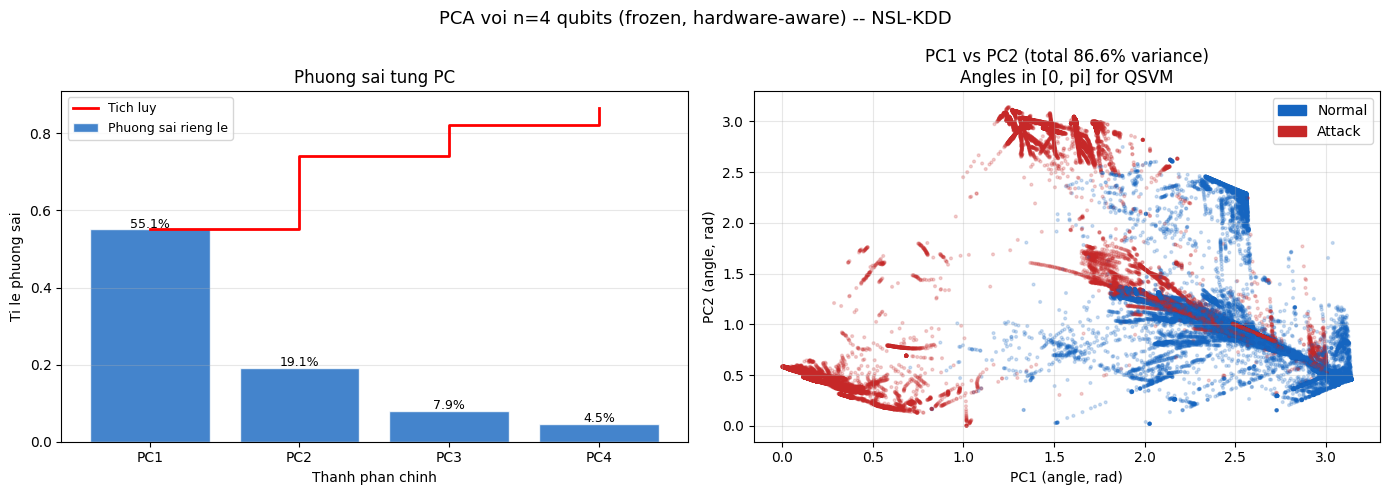

In [24]:
pc_cols = [f'PC{i+1}' for i in range(n_chosen)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'PCA voi n={n_chosen} qubits (frozen, hardware-aware) -- {DATA_TYPE}', fontsize=13)

ax1.bar(pc_cols, pca_final.explained_variance_ratio_,
        color='#1565C0', alpha=0.8, edgecolor='white', label='Phuong sai rieng le')
ax1.step(range(n_chosen), np.cumsum(pca_final.explained_variance_ratio_),
         where='post', color='red', linewidth=2, label='Tich luy')
for i, v in enumerate(pca_final.explained_variance_ratio_):
    ax1.text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontsize=9)
ax1.set_xlabel('Thanh phan chinh'); ax1.set_ylabel('Ti le phuong sai')
ax1.set_title('Phuong sai tung PC'); ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3, axis='y')

cs = ['#1565C0' if yi == 0 else '#C62828' for yi in y]
ax2.scatter(X_train_final[:, 0], X_train_final[:, 1], c=cs, alpha=0.2, s=4)
ax2.set_xlabel('PC1 (angle, rad)'); ax2.set_ylabel('PC2 (angle, rad)')
total_var = np.sum(pca_final.explained_variance_ratio_) * 100
ax2.set_title(f'PC1 vs PC2 (total {total_var:.1f}% variance)\nAngles in [0, pi] for QSVM')
ax2.legend(handles=[mpatches.Patch(color='#1565C0', label='Normal'),
                    mpatches.Patch(color='#C62828', label='Attack')], fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_final_result.png', dpi=150, bbox_inches='tight')
plt.show()


### Pairplot

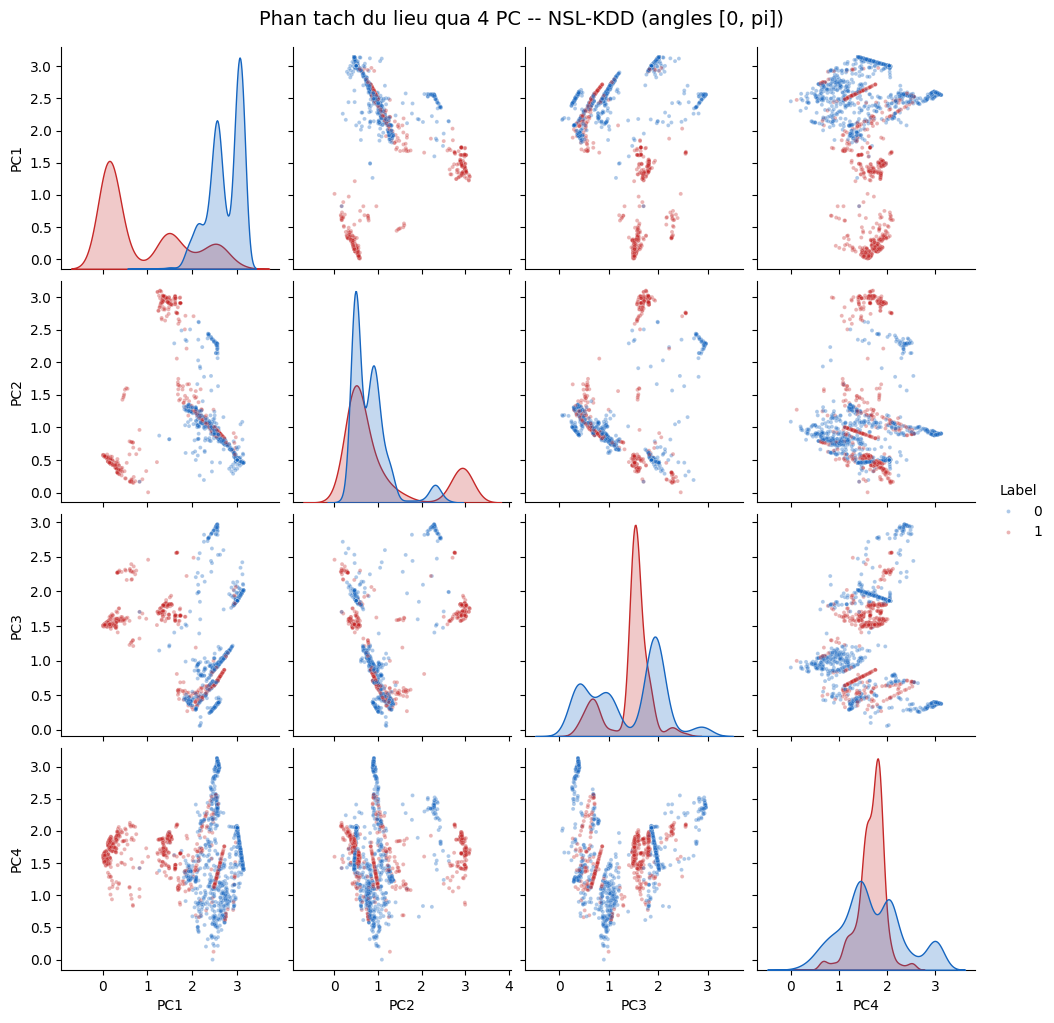

In [25]:
pca_df          = pd.DataFrame(X_train_final, columns=pc_cols)
pca_df['Label'] = y

grid = sns.pairplot(
    pca_df.sample(min(2000, len(pca_df)), random_state=GLOBAL_SEED),
    hue='Label',
    palette={0: '#1565C0', 1: '#C62828'},
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 8}
)
grid.fig.suptitle(f'Phan tach du lieu qua {n_chosen} PC -- {DATA_TYPE} (angles [0, pi])',
                  y=1.02, fontsize=14)
plt.show()


### Phân tích tương quan — tiền đề cho ZZFeatureMap

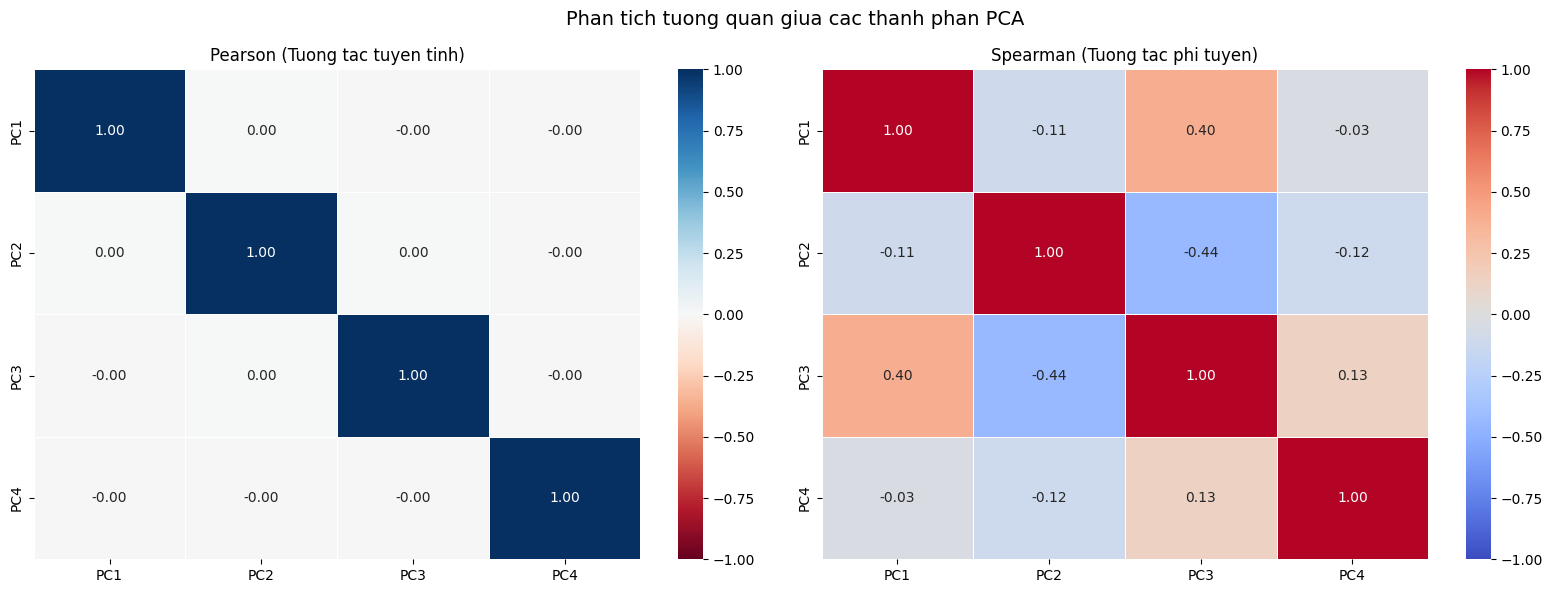

Tuong quan Spearman |r| > 0.2 -- Tien de cho ZZFeatureMap:
   PC2 <-> PC3 : r = -0.437
   PC1 <-> PC3 : r = +0.397


In [26]:
corr_pearson  = pca_df.drop('Label', axis=1).corr(method='pearson')
corr_spearman = pca_df.drop('Label', axis=1).corr(method='spearman')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phan tich tuong quan giua cac thanh phan PCA', fontsize=14)
sns.heatmap(corr_pearson,  annot=True, cmap='RdBu',    fmt='.2f', ax=ax1, linewidths=0.5, vmin=-1, vmax=1)
ax1.set_title('Pearson (Tuong tac tuyen tinh)')
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt='.2f', ax=ax2, linewidths=0.5, vmin=-1, vmax=1)
ax2.set_title('Spearman (Tuong tac phi tuyen)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

sig_pairs = []
for i in range(len(pc_cols)):
    for j in range(i+1, len(pc_cols)):
        val = corr_spearman.loc[pc_cols[i], pc_cols[j]]
        if abs(val) > 0.2:
            sig_pairs.append((pc_cols[i], pc_cols[j], val))

print('Tuong quan Spearman |r| > 0.2 -- Tien de cho ZZFeatureMap:')
if sig_pairs:
    for p1, p2, val in sorted(sig_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'   {p1} <-> {p2} : r = {val:+.3f}')
else:
    print('  Khong co cap dang ke -- cau truc phi tuyen yeu o n nay.')


## 15. Freeze — export artifacts cho C2–C4

Sau khi `n*` được chọn theo rule ở Block D, nó được **freeze**: C2/C3/C4 đọc lại `c1_selection.json` và dùng đúng `n` này, không được chọn lại.

Tên artifact PCA/scaler xuất ra **giống hệt** bản baseline (`pca_{n}components.joblib`, `scaler_minmax_pi.joblib`) để giữ compatibility downstream. `c1_selection.json` là selection contract chính thức: KTA reference được tính trong vùng information-feasible, objective cuối là minimize `Q(n)`, và finite-shot analysis có role `validation_only`.


In [27]:
# -- Ten artifact GIONG HET pca.ipynb goc / baseline, de khong gay bat dong bo voi cac notebook ke sau
PCA_ARTIFACT_NAME    = f'pca_{n_chosen}components.joblib'
SCALER_ARTIFACT_NAME = 'scaler_minmax_pi.joblib'

joblib.dump(pca_final, f'{MODELS_DIR}/{PCA_ARTIFACT_NAME}')
joblib.dump(scaler_q,  f'{MODELS_DIR}/{SCALER_ARTIFACT_NAME}')

# -- CSV audit trail (Block A / B / C) --
pd.DataFrame([{
    'n': r['n'], 'V_n': r['V_n'], 'DBI': r['DBI'], 'inverse_DBI': r['Fe_n'],
    'Fisher_diag': r['S_n'], 'N_zz': r['N_zz'], 'N_cnot': r['N_cnot'],
    'Q_n': r['Q_n'], 'pareto_optimal': r['n'] in pareto_n,
} for r in results_all]).to_csv(f'{OUTPUT_DIR}/c1_dimension_metrics.csv', index=False)

kernel_geom_df.to_csv(f'{OUTPUT_DIR}/c1_kernel_geometry.csv', index=False)
noise_df.to_csv(f'{OUTPUT_DIR}/c1_noise_metrics.csv', index=False)
# -- Strongly-recommended supplementary robustness checks (review sections 5/6/7) --
kta_ci_df.to_csv(f'{OUTPUT_DIR}/c1_kta_bootstrap_ci.csv', index=False)
shot_sens_df.to_csv(f'{OUTPUT_DIR}/c1_shot_sensitivity.csv', index=False)
eps_df.to_csv(f'{OUTPUT_DIR}/c1_epsilon_sensitivity.csv', index=False)

selected_kta = float(kernel_geom_df.loc[kernel_geom_df['n'] == n_chosen, 'KTA'].iloc[0])
selected_d_noise = float(noise_df.loc[noise_df['n'] == n_chosen, 'D_noise'].iloc[0])
selected_delta_kta = float(noise_df.loc[noise_df['n'] == n_chosen, 'delta_KTA'].iloc[0])

c1_selection = {
    'dataset'    : DATA_TYPE,
    'K'          : int(X_train_raw.shape[1]),
    'candidate_n': ALL_N,

    'selection_rule': {
        'variance_threshold': VARIANCE_THRESHOLD,
        'kta_tolerance'     : KTA_TOLERANCE,
        'kta_reference'     : 'maximum KTA among information-feasible dimensions',
        'objective'         : 'minimize CNOT-weighted hardware cost Q(n)',
        'q_n_definition'    : (
            'Q(n) = [N_1q(n) + 5*N_CNOT(n)] / Q_max, with N_1q(n) = n*r, '
            'N_ZZ(n) = r*C(n,2) ZZ interaction pairs per layer, and '
            'N_CNOT(n) = 2*N_ZZ(n) actual CNOT gates (each ZZ interaction '
            'decomposed into a CNOT-RZ-CNOT sequence).'
        ),
    },

    'information_feasible_n'      : feasible_info,
    'kta_max_feasible'            : KTA_MAX_FEASIBLE,
    'kta_max_feasible_n'          : KTA_MAX_FEASIBLE_N,
    'kta_threshold'               : KTA_THRESHOLD,
    'kernel_quality_feasible_n'   : feasible_kernel,
    'final_feasible_n'            : feasible_final,

    'selected_n'                  : int(n_chosen),
    'selected_hardware_cost'      : float(selected_row['Q_n']),
    'selected_n_zz_pairs_layer'   : int(selected_row['N_zz']),
    'selected_n_cnot_total'       : int(selected_row['N_cnot']),
    'n_equals_manuscript_n4'      : bool(n_chosen == 4),

    'variance'      : float(selected_row['V_n']),
    'dbi'           : float(selected_row['DBI']),
    'inverse_dbi'   : float(selected_row['Fe_n']),
    'hardware_cost' : float(selected_row['Q_n']),

    'kernel_geometry': {
        'KTA'            : selected_kta,
        'KTA_max_feasible': KTA_MAX_FEASIBLE,
        'KTA_max_feasible_n': KTA_MAX_FEASIBLE_N,
        'effective_rank' : float(next(r['effective_rank'] for r in kernel_geometry_rows if r['n'] == n_chosen)),
    },

    'finite_shot_validation': {
        'shots'    : NOISE_SHOTS,
        'role'     : 'validation_only',
        'D_noise'  : selected_d_noise,
        'delta_KTA': selected_delta_kta,
    },

    'kernel_subset_seed'  : KERNEL_SEED,
    'kernel_subset_size'  : N_KERNEL_SUBSET,
    'noise_model'         : f'finite_shot_sampling(shots={NOISE_SHOTS}, seed={NOISE_SEED})',

    'threshold_sensitivity': {
        str(T): smallest_n_for_threshold(results_all, T) for T in THRESHOLD_GRID
    },

    'pareto_analysis': {
        'all_candidates_pareto_optimal': bool(len(dominated_n) == 0),
        'dominated_n'                   : dominated_n,
        'role'                          : 'diagnostic_only_not_used_for_selection',
    },

    'weight_sensitivity': {
        'selected_n_frequency_pct': float(freq.get(n_chosen, 0.0)),
        'role'                     : 'supplementary_diagnostic_only_not_used_for_selection',
    },

    'artifacts': {
        'pca'               : PCA_ARTIFACT_NAME,
        'scaler'            : SCALER_ARTIFACT_NAME,
        'dimension_metrics' : 'c1_dimension_metrics.csv',
        'kernel_geometry'   : 'c1_kernel_geometry.csv',
        'noise_metrics'     : 'c1_noise_metrics.csv',
        'tradeoff_fig'      : 'c1_tradeoff.png',
        'kernel_quality_fig': 'c1_kernel_quality.png',
        'noise_robustness_fig': 'c1_noise_robustness.png',
        'kta_bootstrap_ci'    : 'c1_kta_bootstrap_ci.csv',
        'kta_bootstrap_ci_fig': 'c1_kta_bootstrap_ci.png',
        'shot_sensitivity'    : 'c1_shot_sensitivity.csv',
        'shot_sensitivity_fig': 'c1_shot_sensitivity.png',
        'epsilon_sensitivity' : 'c1_epsilon_sensitivity.csv',
    },

    'robustness_checks': {
        'kta_tolerance_sensitivity': {
            'epsilon_grid'      : EPSILON_GRID,
            'n_star_stable'     : bool(len(set(r['n_star'] for r in eps_sensitivity_rows)) == 1),
            'n_star_by_epsilon' : {str(r['epsilon']): r['n_star'] for r in eps_sensitivity_rows},
        },
        'kta_bootstrap_ci': {
            'n_bootstrap': N_BOOTSTRAP,
            'alpha'      : BOOTSTRAP_ALPHA,
            'ci_at_selected_n': {
                'ci_low' : float(kta_ci_df.loc[kta_ci_df['n'] == n_chosen, 'ci_low'].iloc[0]),
                'ci_high': float(kta_ci_df.loc[kta_ci_df['n'] == n_chosen, 'ci_high'].iloc[0]),
            },
        },
        'shot_sensitivity': {
            'shots_grid'       : SHOTS_GRID,
            'n_grid'           : SHOT_SENS_N,
            'reused_shots'     : NOISE_SHOTS,
            'trend_consistent' : bool(all(
                shot_sens_df[shot_sens_df['shots'] == s].sort_values('n')['D_noise'].is_monotonic_increasing
                for s in SHOTS_GRID
            )),
        },
    },

    'frozen_for_downstream': True,
    'notes': ('Gate-level depolarizing/readout/thermal noise is not part of C1 selection; '
              'finite-shot analysis is reported as validation only.'),
}

with open(f'{OUTPUT_DIR}/c1_selection.json', 'w', encoding='utf-8') as f:
    json.dump(c1_selection, f, indent=2)

pd.DataFrame({
    'pc'                 : pc_cols,
    'explained_variance' : pca_final.explained_variance_ratio_,
    'cumulative_variance': np.cumsum(pca_final.explained_variance_ratio_),
}).to_csv(f'{OUTPUT_DIR}/pca_variance_report.csv', index=False)

print('=== FROZEN ARTIFACTS ===')
print(f'  {MODELS_DIR}/{PCA_ARTIFACT_NAME}')
print(f'  {MODELS_DIR}/{SCALER_ARTIFACT_NAME}')
print(f'  {OUTPUT_DIR}/c1_selection.json')
print(f'  {OUTPUT_DIR}/c1_dimension_metrics.csv')
print(f'  {OUTPUT_DIR}/c1_kernel_geometry.csv')
print(f'  {OUTPUT_DIR}/c1_noise_metrics.csv')
print(f'  {OUTPUT_DIR}/c1_kta_bootstrap_ci.csv')
print(f'  {OUTPUT_DIR}/c1_shot_sensitivity.csv')
print(f'  {OUTPUT_DIR}/c1_epsilon_sensitivity.csv')
print(f'  {OUTPUT_DIR}/pca_variance_report.csv')
print()
print(json.dumps(c1_selection, indent=2))
print()
print('C2/C3/C4 phai doc c1_selection.json va KHONG duoc chon lai n.')


=== FROZEN ARTIFACTS ===
  ../models/pca_4components.joblib
  ../models/scaler_minmax_pi.joblib
  ../../data/nslkdd/processed_data/c1_selection.json
  ../../data/nslkdd/processed_data/c1_dimension_metrics.csv
  ../../data/nslkdd/processed_data/c1_kernel_geometry.csv
  ../../data/nslkdd/processed_data/c1_noise_metrics.csv
  ../../data/nslkdd/processed_data/c1_kta_bootstrap_ci.csv
  ../../data/nslkdd/processed_data/c1_shot_sensitivity.csv
  ../../data/nslkdd/processed_data/c1_epsilon_sensitivity.csv
  ../../data/nslkdd/processed_data/pca_variance_report.csv

{
  "dataset": "NSL-KDD",
  "K": 20,
  "candidate_n": [
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10
  ],
  "selection_rule": {
    "variance_threshold": 0.85,
    "kta_tolerance": 0.05,
    "kta_reference": "maximum KTA among information-feasible dimensions",
    "objective": "minimize CNOT-weighted hardware cost Q(n)",
    "q_n_definition": "Q(n) = [N_1q(n) + 5*N_CNOT(n)] / Q_max, with N_1q(n) = n*r, N_ZZ(n) = r*C

## 16. Paper-ready summary


In [28]:
print('=' * 72)
print('  CONTRIBUTION 1 -- HARDWARE-AWARE QUANTUM EMBEDDING-DIMENSION SELECTION')
print(f'  Dataset: {DATA_TYPE}')
print('=' * 72)
print(f'  [Input]                K={X_train_raw.shape[1]} features (SelectKBest, ANOVA F)')
print(f'  [Candidates evaluated] n in {ALL_N}')
print()
print(f'  [Block A -- Pareto diagnostic]   Pareto-optimal n: {pareto_n}')
print(f'                                   Dominated n     : {dominated_n if dominated_n else "none"}')
print()
print(f'  [Block A -- Threshold sensitivity]')
for T in THRESHOLD_GRID:
    n_T = smallest_n_for_threshold(results_all, T)
    print(f'    T={T:.0%}  -> smallest information-feasible n = {n_T}')
print()
print(f'  [Block B -- Kernel geometry]     KTA range [{kernel_geom_df["KTA"].min():.4f}, {kernel_geom_df["KTA"].max():.4f}]')
print(f'                                      KTA_max within V>={VARIANCE_THRESHOLD:.0%}: {KTA_MAX_FEASIBLE:.4f} at n={KTA_MAX_FEASIBLE_N}')
print(f'  [Block C -- Finite-shot validation] D_noise range [{noise_df["D_noise"].min():.4f}, {noise_df["D_noise"].max():.4f}]')
print(f'                                      shots={NOISE_SHOTS}, role=validation_only')
print()
print('  [Block D -- Selection rule]')
print(f'    1. V(n)>={VARIANCE_THRESHOLD:.0%} -> {feasible_info}')
print(f'    2. KTA(n)>={KTA_THRESHOLD:.4f} within information-feasible set -> {feasible_kernel}')
print(f'    3. n* = argmin Q(n) over {feasible_final} -> {n_chosen}')
print(f'  [Selected / frozen n]        n = {n_chosen}   (n == 4 manuscript value: {n_chosen == 4})')
print(f'    Variance retained    = {selected_row["V_n"]:.2%}')
print(f'    DBI / 1-DBI          = {selected_row["DBI"]:.4f} / {selected_row["Fe_n"]:.4f}')
print(f'    Hardware cost Q(n)   = {selected_row["Q_n"]:.4f}')
print(f'    ZZ interaction pairs / layer = {n_chosen*(n_chosen-1)//2}')
print(f'    CNOTs / layer                = {2*(n_chosen*(n_chosen-1)//2)}')
print(f'    Total CNOT count (r={REPS} layers) = {selected_row["N_cnot"]}')
kta_sel = float(kernel_geom_df.loc[kernel_geom_df['n'] == n_chosen, 'KTA'].iloc[0])
dnoise_sel = float(noise_df.loc[noise_df['n'] == n_chosen, 'D_noise'].iloc[0])
print(f'    KTA(n)               = {kta_sel:.4f}  (KTA_max_feasible={KTA_MAX_FEASIBLE:.4f} at n={KTA_MAX_FEASIBLE_N})')
print(f'    D_noise(n)           = {dnoise_sel:.4f}  (validation only, shots={NOISE_SHOTS})')
print()
print(f'  [Weight sensitivity, supplementary]  n={n_chosen} selected in {freq.get(n_chosen,0.0):.1f}% of weight trials')
print('    (informational only -- scalarized objective is NOT the selection mechanism)')
print()
print('  [Narrative for manuscript]')
print('  "We impose an a priori 85% cumulative-variance requirement. Among dimensions')
print('   satisfying this requirement, we evaluate quantum-kernel alignment and retain')
print('   dimensions within 5% of the best KTA in the information-feasible region.')
print(f'   This yields the feasible set {feasible_final}. We then select the minimum')
print(f'   CNOT-weighted hardware cost within this set, resulting in n={n_chosen}.')
print('   The selected configuration is frozen before downstream experiments.')
print('   Finite-shot analysis is reported separately as a robustness validation and')
print('   is not used as a selection criterion."')
print('=' * 72)


  CONTRIBUTION 1 -- HARDWARE-AWARE QUANTUM EMBEDDING-DIMENSION SELECTION
  Dataset: NSL-KDD
  [Input]                K=20 features (SelectKBest, ANOVA F)
  [Candidates evaluated] n in [2, 3, 4, 5, 6, 7, 8, 9, 10]

  [Block A -- Pareto diagnostic]   Pareto-optimal n: [2, 3, 4, 5, 6, 7, 8, 9, 10]
                                   Dominated n     : none

  [Block A -- Threshold sensitivity]
    T=80%  -> smallest information-feasible n = 3
    T=85%  -> smallest information-feasible n = 4
    T=90%  -> smallest information-feasible n = 5
    T=95%  -> smallest information-feasible n = 7

  [Block B -- Kernel geometry]     KTA range [0.1537, 0.3297]
                                      KTA_max within V>=85%: 0.2439 at n=5
  [Block C -- Finite-shot validation] D_noise range [0.0000, 0.0003]
                                      shots=1024, role=validation_only

  [Block D -- Selection rule]
    1. V(n)>=85% -> [4, 5, 6, 7, 8, 9, 10]
    2. KTA(n)>=0.2317 within information-feasible set ->